# Melbourne House Price Prediction
Predicting residential property prices in Melbourne, Australia using ML regression models.
**Dataset:** Melbourne Housing Snapshot (Kaggle) | **Best Result:** LightGBM  R² = 0.94

# Libraries & Dependencies
Importing libraries for data manipulation, visualization, preprocessing, and modelling.

In [73]:
import re
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb
import missingno as msno

from scipy.stats import zscore

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder


# Pipeline
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance


# Evaluation
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error as root_mean_squared_error  # Optional alias if you're using it like this


import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Loading the Dataset
Dataset contains 13,580 Melbourne property listings with 21 features including location, size, property type, and sale details.

In [74]:
mel_data = pd.read_csv('melb_data.csv') 

# Exploratory Data Analysis (EDA)
Examining distributions, missing values, and relationships between features.

Separate helper functions are defined for categorical and numerical variables.

In [75]:
mel_data.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,"1,480,000.00",S,Biggin,3/12/2016,2.50,"3,067.00",...,1.00,1.00,202.00,NaN,NaN,Yarra,-37.80,145.00,Northern Metropolitan,"4,019.00"
1,Abbotsford,25 Bloomburg St,2,h,"1,035,000.00",S,Biggin,4/02/2016,2.50,"3,067.00",...,1.00,0.00,156.00,79.00,"1,900.00",Yarra,-37.81,144.99,Northern Metropolitan,"4,019.00"
2,Abbotsford,5 Charles St,3,h,"1,465,000.00",SP,Biggin,4/03/2017,2.50,"3,067.00",...,2.00,0.00,134.00,150.00,"1,900.00",Yarra,-37.81,144.99,Northern Metropolitan,"4,019.00"
3,Abbotsford,40 Federation La,3,h,"850,000.00",PI,Biggin,4/03/2017,2.50,"3,067.00",...,2.00,1.00,94.00,NaN,NaN,Yarra,-37.80,145.00,Northern Metropolitan,"4,019.00"
4,Abbotsford,55a Park St,4,h,"1,600,000.00",VB,Nelson,4/06/2016,2.50,"3,067.00",...,1.00,2.00,120.00,142.00,"2,014.00",Yarra,-37.81,144.99,Northern Metropolitan,"4,019.00"


In [76]:
mel_data.shape

(13580, 21)

In [77]:
mel_data.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='str')

In [78]:
mel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

<Axes: >

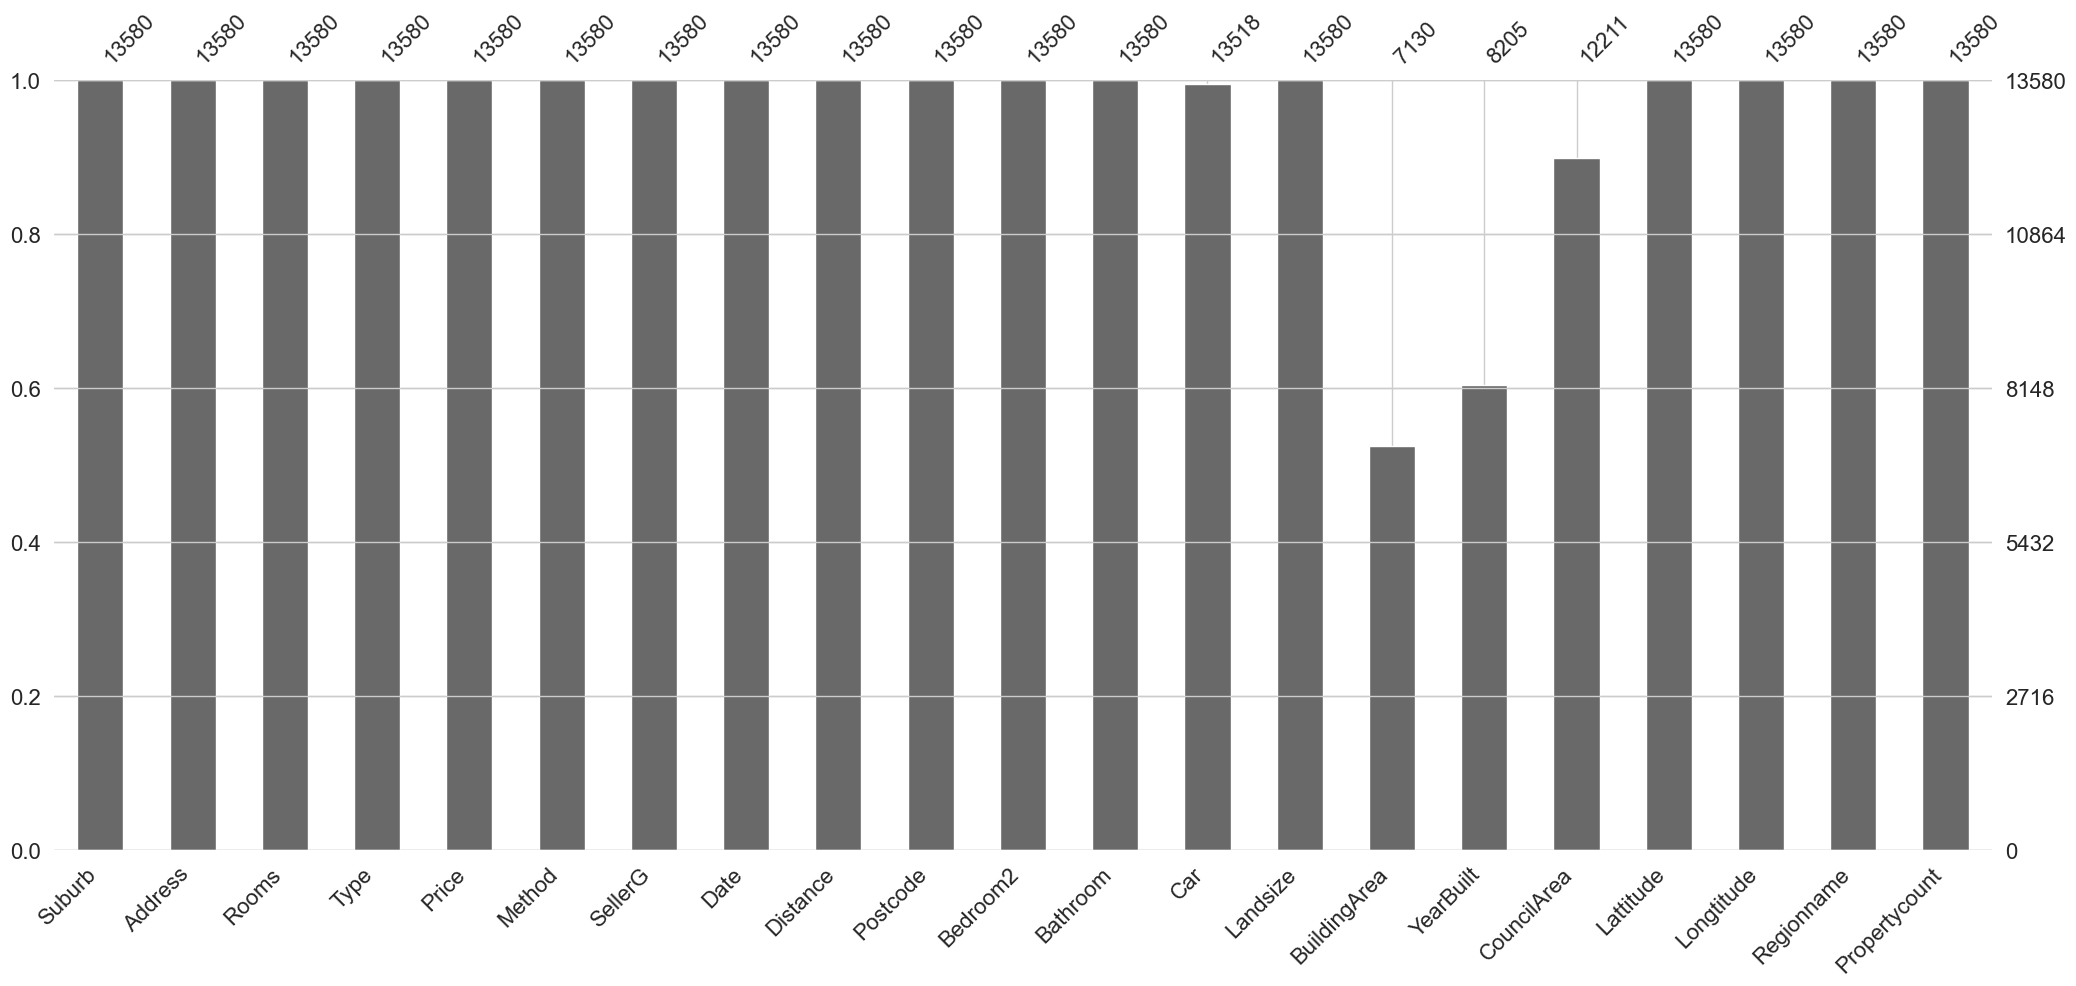

In [79]:
msno.bar(mel_data)

In [80]:
mel_data.isnull().sum() / len(mel_data) * 100

Suburb           0.00
Address          0.00
Rooms            0.00
Type             0.00
Price            0.00
Method           0.00
SellerG          0.00
Date             0.00
Distance         0.00
Postcode         0.00
Bedroom2         0.00
Bathroom         0.00
Car              0.46
Landsize         0.00
BuildingArea    47.50
YearBuilt       39.58
CouncilArea     10.08
Lattitude        0.00
Longtitude       0.00
Regionname       0.00
Propertycount    0.00
dtype: float64

In [81]:
mel_data.isnull().sum() / len(mel_data) * 100

Suburb           0.00
Address          0.00
Rooms            0.00
Type             0.00
Price            0.00
Method           0.00
SellerG          0.00
Date             0.00
Distance         0.00
Postcode         0.00
Bedroom2         0.00
Bathroom         0.00
Car              0.46
Landsize         0.00
BuildingArea    47.50
YearBuilt       39.58
CouncilArea     10.08
Lattitude        0.00
Longtitude       0.00
Regionname       0.00
Propertycount    0.00
dtype: float64

In [82]:
def univariate_categorical(column):
    
    print(f"Unique values in variable -{column}-")    
    print(mel_data[column].unique())
    
    print("-" * 100)    
    print(f"Most frequent value: {mel_data[column].mode()[0]}")
    print("-" * 100)
    
    category_counts = mel_data[column].value_counts().reset_index()
    print("Percentage of categories")
    print(round(category_counts['count'] / category_counts['count'].sum() * 100, 2))
    print("-" * 100)

    print(f"Descriptive statistics related to categories in -{column}- variable.")
    print(category_counts.describe())
    print("-" * 100)
    
    plt.figure(figsize=(10, 6))
    sb.barplot(x=column, y='count', data=category_counts.head(20), color = 'green')
    plt.title(f"Category distribution in {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(fontsize = 10, rotation = 45)
    plt.tight_layout()
    plt.show()

def univariate_numerical(column):
    col_data = mel_data[column].dropna()
    
    print(f"Descriptive statistics for variable -{column}-")
    print(col_data.describe())
    print("-" * 100)
    
    skew_value = col_data.skew()
    print(f"Skewness of '{column}': {skew_value:.2f}")
    print("Interpretation:")
    if skew_value > 1:
        print("  ➤ Highly right-skewed")
    elif skew_value > 0.5:
        print("  ➤ Moderately right-skewed")
    elif skew_value < -1:
        print("  ➤ Highly left-skewed")
    elif skew_value < -0.5:
        print("  ➤ Moderately left-skewed")
    else:
        print("  ➤ Approximately symmetric")
    print("-" * 100)

    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    lower_outliers = col_data[col_data < lower_bound]
    upper_outliers = col_data[col_data > upper_bound]

    print("IQR Method:")
    print(f"  Q1: {Q1}")
    print(f"  Q3: {Q3}")
    print(f"  IQR: {IQR}")
    print(f"  Lower Bound: {lower_bound}")
    print(f"  Upper Bound: {upper_bound}")
    print(f"  Lower outliers: {len(lower_outliers)}, percentage {round(len(lower_outliers) / len(mel_data) * 100, 2)}%")
    print(f"  Upper outliers: {len(upper_outliers)}, percentage {round(len(upper_outliers) / len(mel_data) * 100, 2)}%")
    print(f"  Total outliers: {len(lower_outliers) + len(upper_outliers)}")
    print("-" * 100)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [2, 1]})

    sb.kdeplot(col_data, ax=axes[0], fill=True, color='skyblue')
    axes[0].set_title(f"KDE Plot of {column}")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Density")

    sb.boxplot(y=col_data, ax=axes[1], color='orange')
    axes[1].set_title(f"Boxplot of {column}")
    axes[1].yaxis.tick_right()
    axes[1].yaxis.set_label_position("right")

    plt.tight_layout()
    plt.show()

Unique values in variable -Suburb-
<StringArray>
[  'Abbotsford', 'Airport West',  'Albert Park',   'Alphington',
       'Altona', 'Altona North',     'Armadale',   'Ascot Vale',
    'Ashburton',      'Ashwood',
 ...
   'Yarra Glen',   'Brookfield',      'Emerald',   'Whittlesea',
     'Burnside',      'Attwood',       'Wallan', 'New Gisborne',
     'Plumpton',      'Monbulk']
Length: 314, dtype: str
----------------------------------------------------------------------------------------------------
Most frequent value: Reservoir
----------------------------------------------------------------------------------------------------
Percentage of categories
0     2.64
1     1.91
2     1.83
3     1.76
4     1.63
      ... 
309   0.01
310   0.01
311   0.01
312   0.01
313   0.01
Name: count, Length: 314, dtype: float64
----------------------------------------------------------------------------------------------------
Descriptive statistics related to categories in -Suburb- variable.
       c

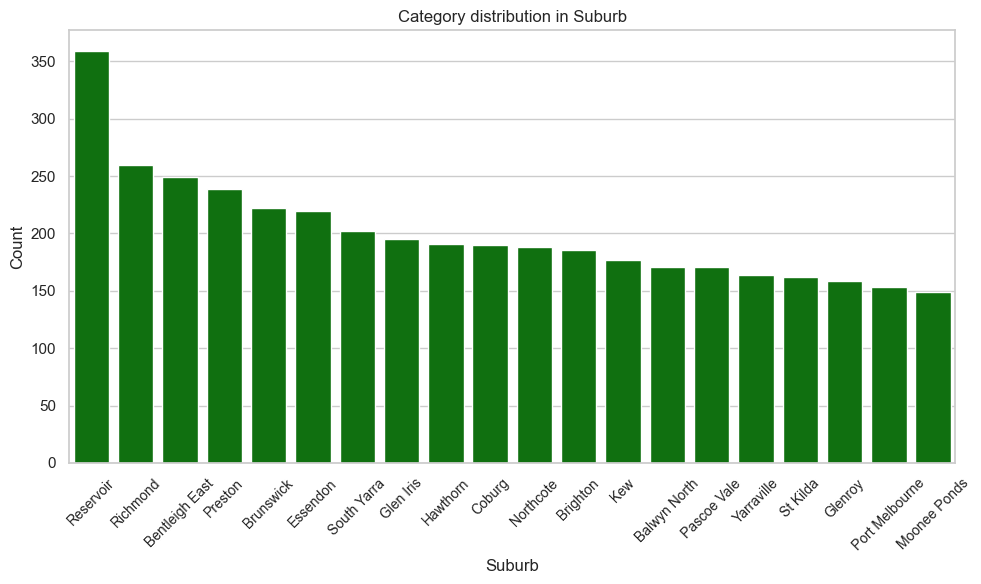

In [83]:
univariate_categorical('Suburb')

Unique values in variable -Rooms-
[ 2  3  4  1  6  5  8  7 10]
----------------------------------------------------------------------------------------------------
Most frequent value: 3
----------------------------------------------------------------------------------------------------
Percentage of categories
0   43.31
1   26.86
2   19.79
3    5.01
4    4.39
5    0.49
6    0.07
7    0.06
8    0.01
Name: count, dtype: float64
----------------------------------------------------------------------------------------------------
Descriptive statistics related to categories in -Rooms- variable.
       Rooms    count
count   9.00     9.00
mean    5.11 1,508.89
std     2.93 2,105.12
min     1.00     1.00
25%     3.00    10.00
50%     5.00   596.00
75%     7.00 2,688.00
max    10.00 5,881.00
----------------------------------------------------------------------------------------------------


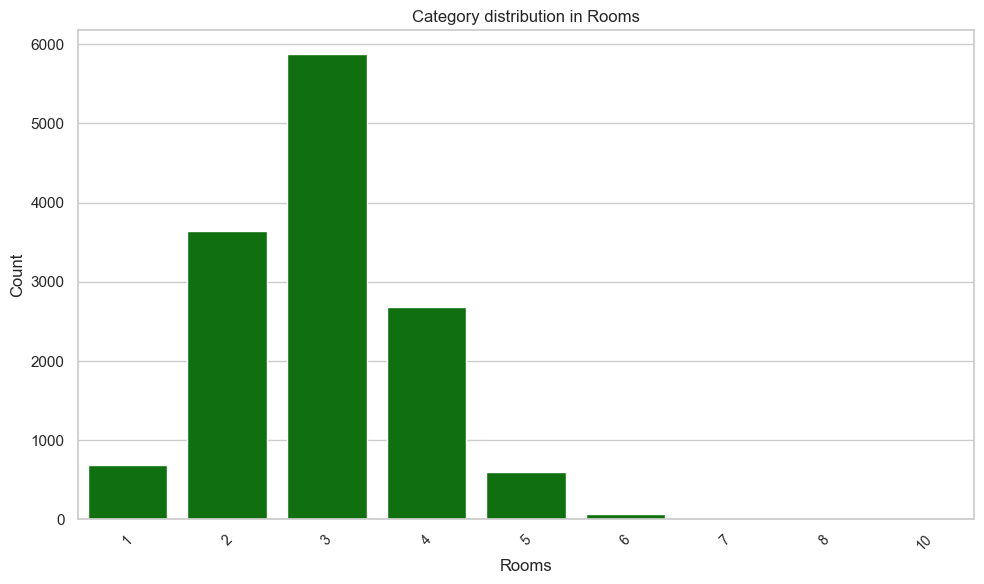

In [84]:
univariate_categorical('Rooms')

In [85]:
mel_data['Type'] = mel_data['Type'].replace({
    'h': 'House',
    'u': 'Unit/Apartment',
    't': 'Townhouse'
})

Unique values in variable -Type-
<StringArray>
['House', 'Unit/Apartment', 'Townhouse']
Length: 3, dtype: str
----------------------------------------------------------------------------------------------------
Most frequent value: House
----------------------------------------------------------------------------------------------------
Percentage of categories
0   69.58
1   22.22
2    8.20
Name: count, dtype: float64
----------------------------------------------------------------------------------------------------
Descriptive statistics related to categories in -Type- variable.
         count
count     3.00
mean  4,526.67
std   4,367.77
min   1,114.00
25%   2,065.50
50%   3,017.00
75%   6,233.00
max   9,449.00
----------------------------------------------------------------------------------------------------


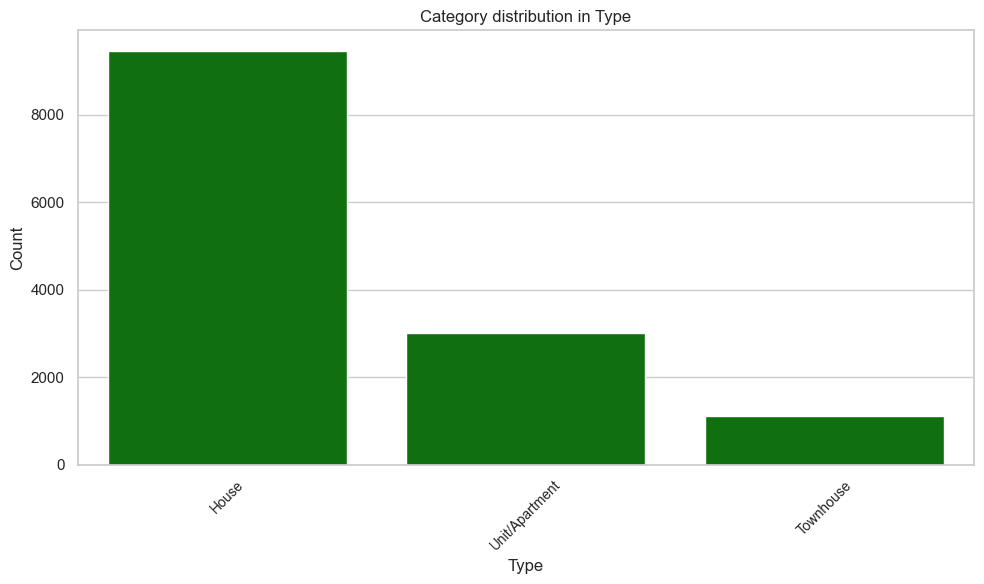

In [86]:
univariate_categorical('Type')

Descriptive statistics for variable -Price-
count      13,580.00
mean    1,075,684.08
std       639,310.72
min        85,000.00
25%       650,000.00
50%       903,000.00
75%     1,330,000.00
max     9,000,000.00
Name: Price, dtype: float64
----------------------------------------------------------------------------------------------------
Skewness of 'Price': 2.24
Interpretation:
  ➤ Highly right-skewed
----------------------------------------------------------------------------------------------------
IQR Method:
  Q1: 650000.0
  Q3: 1330000.0
  IQR: 680000.0
  Lower Bound: -370000.0
  Upper Bound: 2350000.0
  Lower outliers: 0, percentage 0.0%
  Upper outliers: 612, percentage 4.51%
  Total outliers: 612
----------------------------------------------------------------------------------------------------


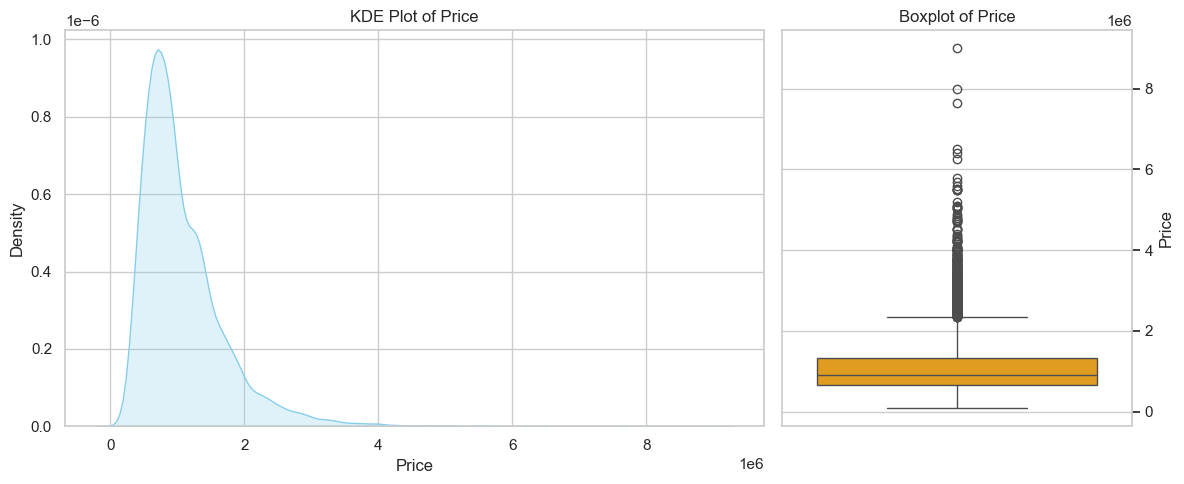

In [87]:
univariate_numerical('Price')

In [88]:
mel_data['Method'] = mel_data['Method'].replace({
    'S': 'Sold at Auction',
    'SP': 'Sold Prior Auction',
    'PI': 'Passed In',
    'VB': 'Vendor Bid Only',
    'SA': 'Sold After Auction'
})

Unique values in variable -Method-
<StringArray>
[   'Sold at Auction', 'Sold Prior Auction',          'Passed In',
    'Vendor Bid Only', 'Sold After Auction']
Length: 5, dtype: str
----------------------------------------------------------------------------------------------------
Most frequent value: Sold at Auction
----------------------------------------------------------------------------------------------------
Percentage of categories
0   66.44
1   12.54
2   11.52
3    8.83
4    0.68
Name: count, dtype: float64
----------------------------------------------------------------------------------------------------
Descriptive statistics related to categories in -Method- variable.
         count
count     5.00
mean  2,716.00
std   3,581.40
min      92.00
25%   1,199.00
50%   1,564.00
75%   1,703.00
max   9,022.00
----------------------------------------------------------------------------------------------------


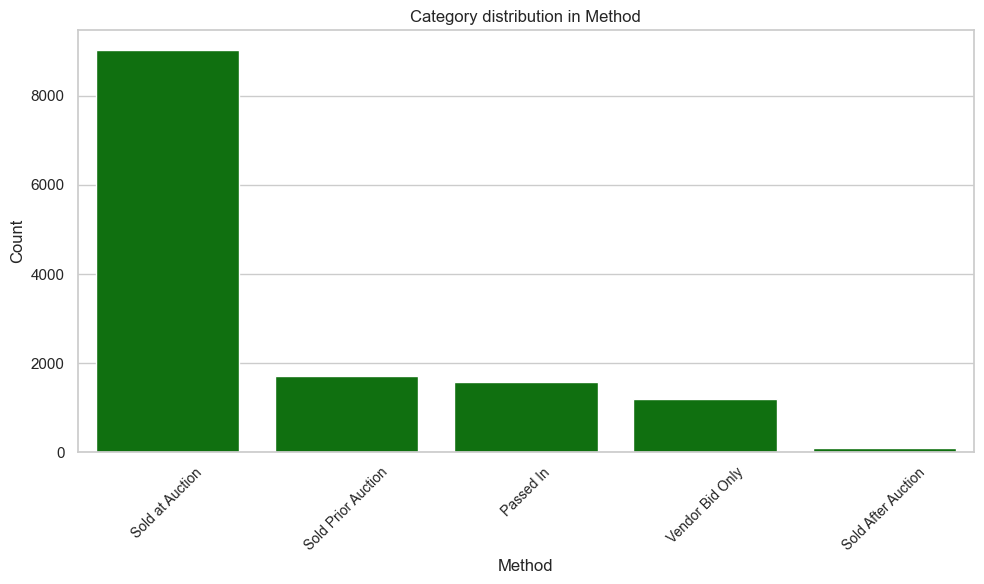

In [89]:
univariate_categorical('Method')

Unique values in variable -SellerG-
<StringArray>
[  'Biggin',   'Nelson',   'Jellis',     'Greg',   'LITTLE',  'Collins',
      'Kay',   'Beller', 'Marshall',     'Brad',
 ...
    'Roger',  'Follett',       'Le',   'Joseph', 'Boutique',     'Area',
       'SN',      'PRD',  'Rexhepi',    'Point']
Length: 268, dtype: str
----------------------------------------------------------------------------------------------------
Most frequent value: Nelson
----------------------------------------------------------------------------------------------------
Percentage of categories
0     11.52
1      9.69
2      8.59
3      7.44
4      5.16
       ... 
263    0.01
264    0.01
265    0.01
266    0.01
267    0.01
Name: count, Length: 268, dtype: float64
----------------------------------------------------------------------------------------------------
Descriptive statistics related to categories in -SellerG- variable.
         count
count   268.00
mean     50.67
std     175.86
min       1.00
25%  

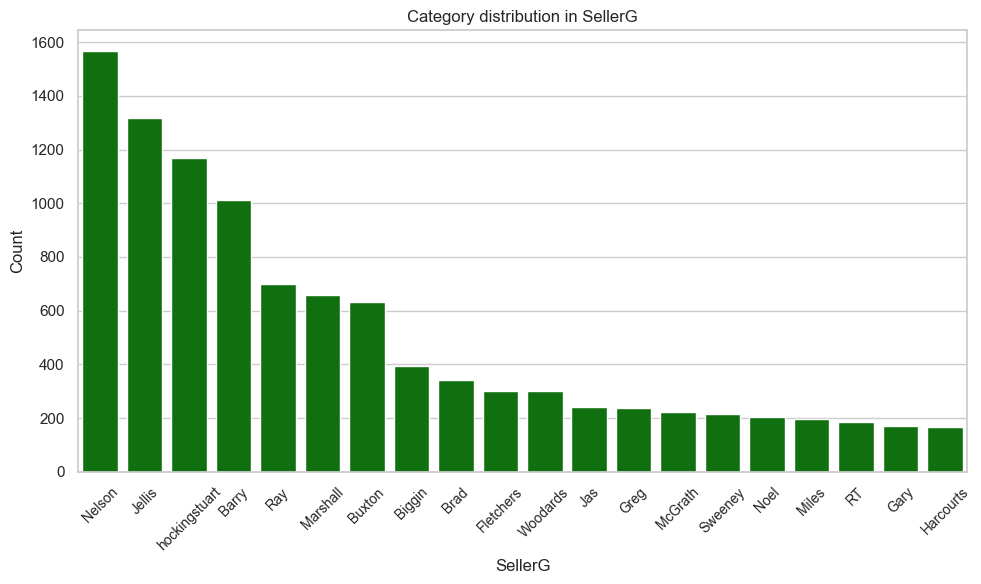

In [90]:
univariate_categorical('SellerG')

Unique values in variable -Date-
<StringArray>
[ '3/12/2016',  '4/02/2016',  '4/03/2017',  '4/06/2016',  '7/05/2016',
  '8/10/2016', '12/11/2016', '13/08/2016', '14/05/2016', '15/10/2016',
 '16/07/2016', '17/09/2016', '18/03/2017', '18/06/2016', '19/11/2016',
 '22/08/2016', '24/09/2016', '25/02/2017', '26/07/2016', '27/11/2016',
 '28/05/2016', '30/07/2016',  '3/09/2016',  '6/08/2016',  '7/11/2016',
 '10/09/2016', '10/12/2016', '11/02/2017', '16/04/2016', '22/05/2016',
 '23/04/2016', '12/06/2016', '27/06/2016', '28/08/2016', '11/03/2017',
 '28/01/2016',  '6/05/2017',  '8/04/2017', '29/04/2017', '13/05/2017',
 '20/05/2017', '22/04/2017',  '1/07/2017',  '3/06/2017', '17/06/2017',
 '24/06/2017', '27/05/2017',  '8/07/2017', '12/08/2017', '15/07/2017',
 '22/07/2017', '29/07/2017',  '3/09/2017',  '9/09/2017', '16/09/2017',
 '19/08/2017', '23/09/2017', '26/08/2017']
Length: 58, dtype: str
----------------------------------------------------------------------------------------------------
Most 

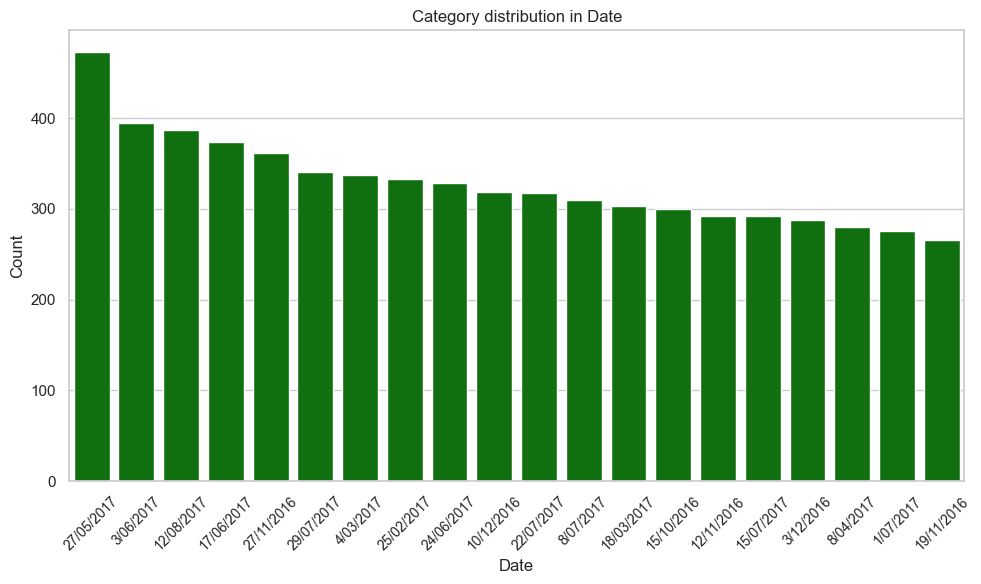

In [91]:
univariate_categorical('Date')

Descriptive statistics for variable -Distance-
count   13,580.00
mean        10.14
std          5.87
min          0.00
25%          6.10
50%          9.20
75%         13.00
max         48.10
Name: Distance, dtype: float64
----------------------------------------------------------------------------------------------------
Skewness of 'Distance': 1.68
Interpretation:
  ➤ Highly right-skewed
----------------------------------------------------------------------------------------------------
IQR Method:
  Q1: 6.1
  Q3: 13.0
  IQR: 6.9
  Lower Bound: -4.250000000000002
  Upper Bound: 23.35
  Lower outliers: 0, percentage 0.0%
  Upper outliers: 411, percentage 3.03%
  Total outliers: 411
----------------------------------------------------------------------------------------------------


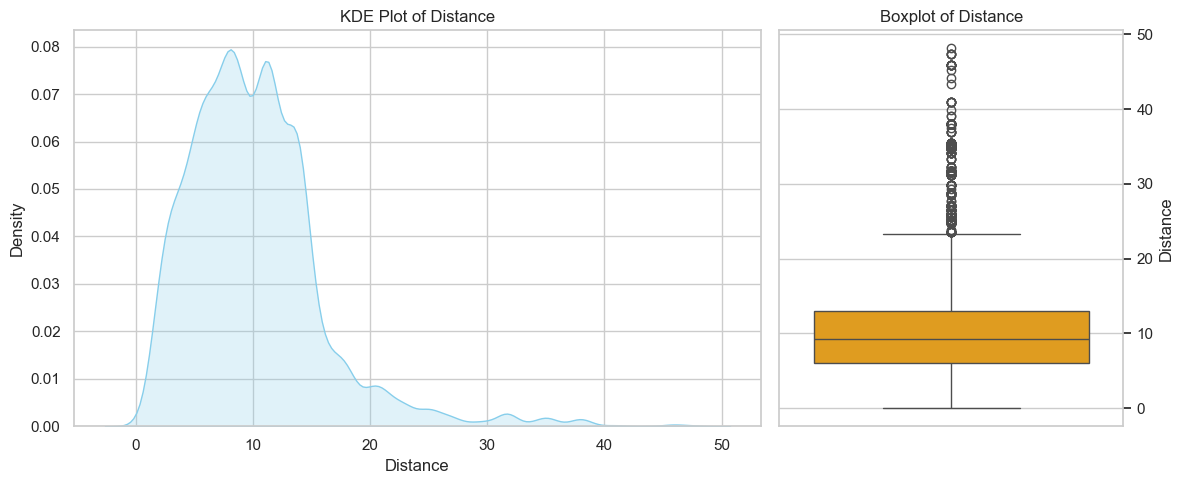

In [92]:
univariate_numerical('Distance')

Unique values in variable -Postcode-
[3067. 3042. 3206. 3078. 3018. 3025. 3143. 3032. 3147. 3034. 3183. 3103.
 3104. 3204. 3165. 3128. 3019. 3186. 3187. 3056. 3055. 3105. 3125. 3124.
 3126. 3054. 3163. 3162. 3161. 3148. 3068. 3058. 3066. 3108. 3084. 3185.
 3184. 3040. 3041. 3065. 3031. 3011. 3146. 3046. 3043. 3188. 3122. 3081.
 3166. 3079. 3021. 3033. 3101. 3102. 3144. 3012. 3145. 3000. 3127. 3039.
 3189. 3015. 3051. 3070. 3167. 3052. 3044. 3207. 3181. 3072. 3073. 3121.
 3205. 3141. 3006. 3182. 3020. 3107. 3071. 3142. 3087. 3003. 3016. 3085.
 3013. 3057. 3061. 3053. 3002. 3060. 3123. 3047. 3083. 3008. 3153. 3193.
 3806. 3155. 3088. 3023. 3151. 3192. 3064. 3977. 3136. 3175. 3089. 3172.
 3109. 3111. 3754. 3095. 3076. 3131. 3199. 3200. 3437. 3803. 3777. 3190.
 3037. 3038. 3173. 3075. 3093. 3337. 3082. 3132. 3094. 3195. 3149. 3805.
 3030. 3135. 3335. 3178. 3191. 3198. 3752. 3171. 3429. 3029. 3154. 3074.
 3133. 3152. 3049. 3027. 3750. 3024. 3130. 3196. 3197. 3168. 3177. 3156.
 3150. 3059. 3

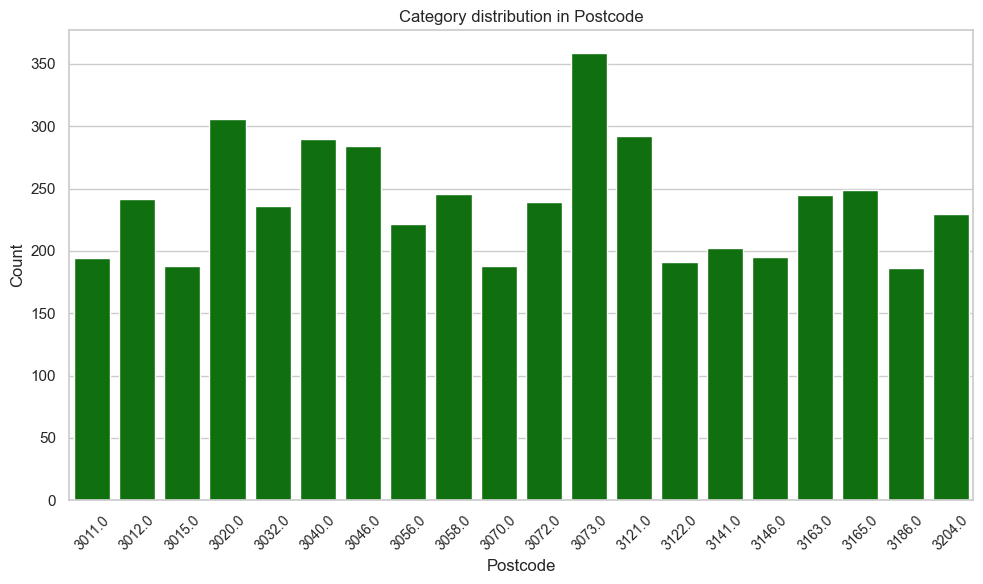

In [93]:
univariate_categorical('Postcode')

Unique values in variable -Bedroom2-
[ 2.  3.  4.  1.  6.  5.  0.  8.  9.  7. 20. 10.]
----------------------------------------------------------------------------------------------------
Most frequent value: 3.0
----------------------------------------------------------------------------------------------------
Percentage of categories
0    43.42
1    27.52
2    19.15
3     5.09
4     4.09
5     0.46
6     0.12
7     0.07
8     0.04
9     0.02
10    0.01
11    0.01
Name: count, dtype: float64
----------------------------------------------------------------------------------------------------
Descriptive statistics related to categories in -Bedroom2- variable.
       Bedroom2    count
count     12.00    12.00
mean       6.25 1,131.67
std        5.36 1,928.64
min        0.00     1.00
25%        2.75     4.50
50%        5.50    39.50
75%        8.25 1,168.50
max       20.00 5,896.00
----------------------------------------------------------------------------------------------------


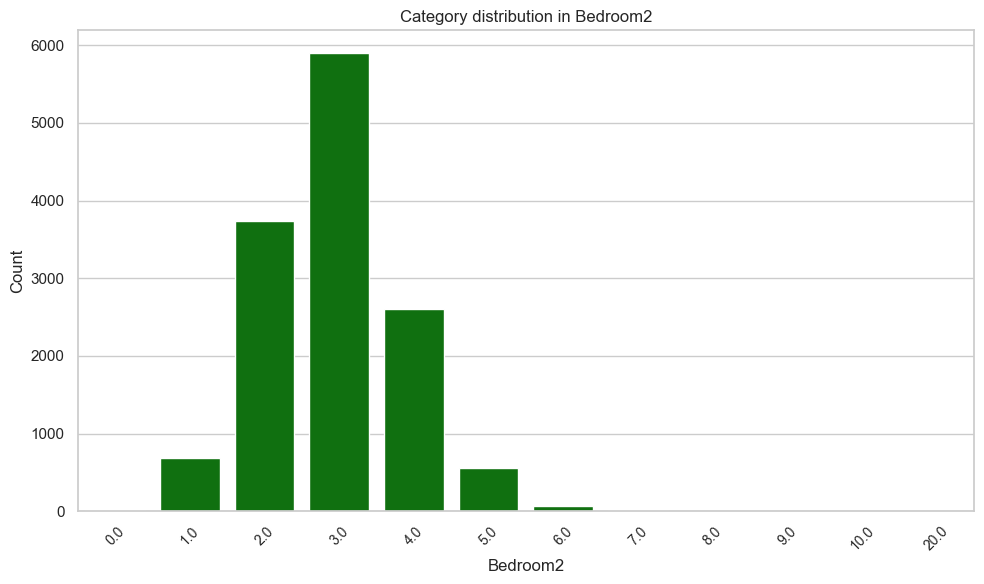

In [94]:
univariate_categorical('Bedroom2')

Unique values in variable -Bathroom-
[1. 2. 3. 4. 0. 7. 5. 6. 8.]
----------------------------------------------------------------------------------------------------
Most frequent value: 1.0
----------------------------------------------------------------------------------------------------
Percentage of categories
0   55.32
1   36.63
2    6.75
3    0.78
4    0.25
5    0.21
6    0.04
7    0.01
8    0.01
Name: count, dtype: float64
----------------------------------------------------------------------------------------------------
Descriptive statistics related to categories in -Bathroom- variable.
       Bathroom    count
count      9.00     9.00
mean       4.00 1,508.89
std        2.74 2,773.41
min        0.00     2.00
25%        2.00     5.00
50%        4.00    34.00
75%        6.00   917.00
max        8.00 7,512.00
----------------------------------------------------------------------------------------------------


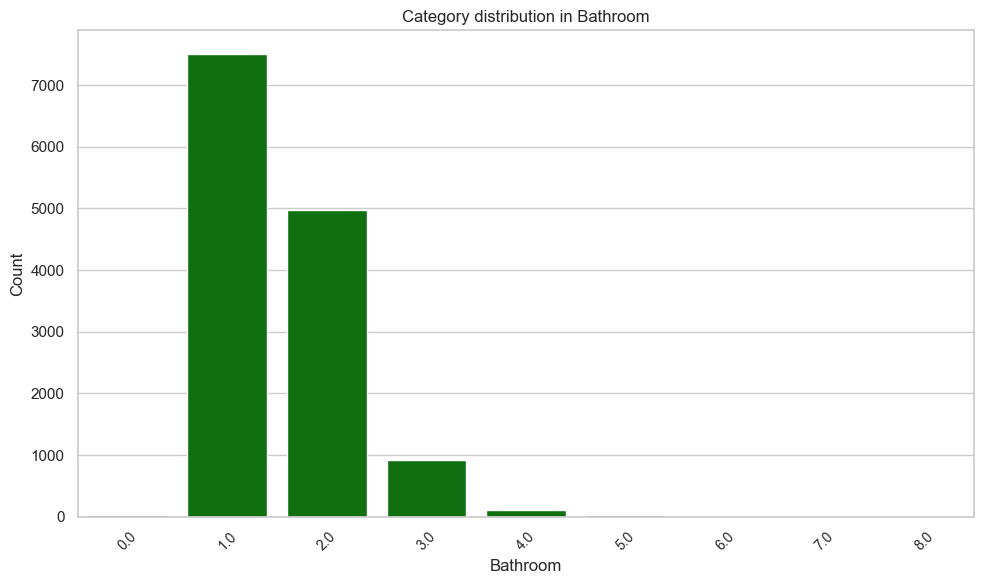

In [95]:
univariate_categorical('Bathroom')

Unique values in variable -Car-
[ 1.  0.  2.  6.  5.  4.  3.  8.  7.  9. 10. nan]
----------------------------------------------------------------------------------------------------
Most frequent value: 2.0
----------------------------------------------------------------------------------------------------
Percentage of categories
0    41.36
1    40.75
2     7.59
3     5.53
4     3.74
5     0.47
6     0.40
7     0.07
8     0.06
9     0.02
10    0.01
Name: count, dtype: float64
----------------------------------------------------------------------------------------------------
Descriptive statistics related to categories in -Car- variable.
        Car    count
count 11.00    11.00
mean   5.00 1,228.91
std    3.32 2,164.98
min    0.00     1.00
25%    2.50     8.50
50%    5.00    63.00
75%    7.50   887.00
max   10.00 5,591.00
----------------------------------------------------------------------------------------------------


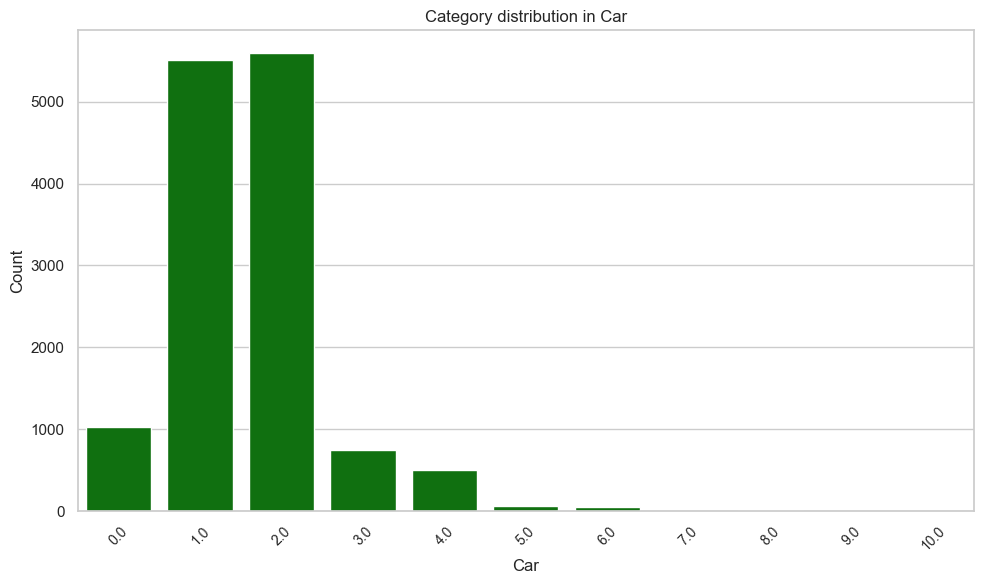

In [96]:
univariate_categorical('Car')

Descriptive statistics for variable -BuildingArea-
count    7,130.00
mean       151.97
std        541.01
min          0.00
25%         93.00
50%        126.00
75%        174.00
max     44,515.00
Name: BuildingArea, dtype: float64
----------------------------------------------------------------------------------------------------
Skewness of 'BuildingArea': 77.69
Interpretation:
  ➤ Highly right-skewed
----------------------------------------------------------------------------------------------------
IQR Method:
  Q1: 93.0
  Q3: 174.0
  IQR: 81.0
  Lower Bound: -28.5
  Upper Bound: 295.5
  Lower outliers: 0, percentage 0.0%
  Upper outliers: 353, percentage 2.6%
  Total outliers: 353
----------------------------------------------------------------------------------------------------


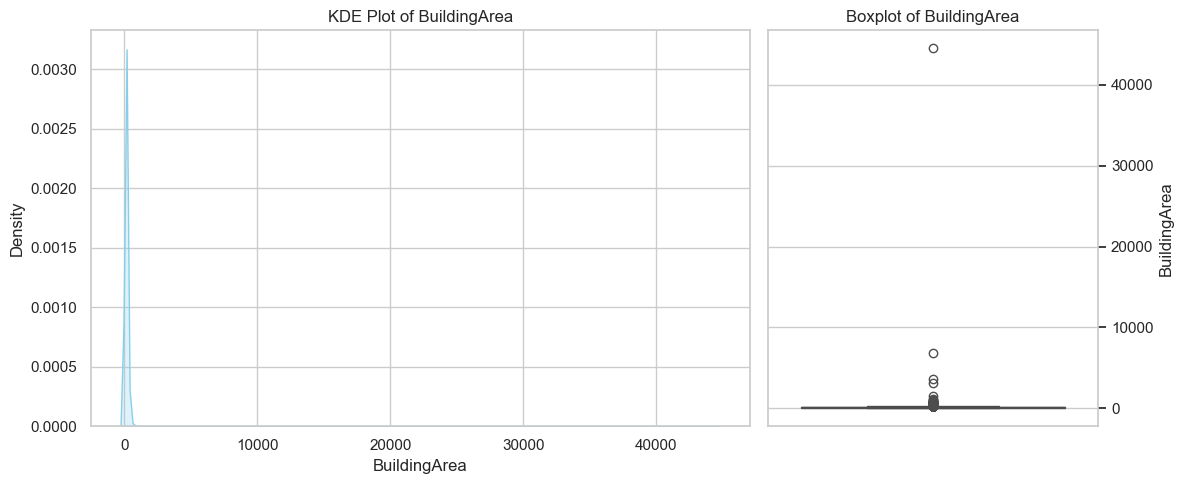

In [97]:
univariate_numerical('BuildingArea')

Unique values in variable -YearBuilt-
[  nan 1900. 2014. 1910. 1890. 2005. 2009. 1880. 1985. 2010. 1970. 2013.
 2012. 1920. 1950. 1998. 1930. 2016. 1965. 1980. 2011. 2015. 1975. 1993.
 1960. 2003. 1995. 1996. 2000. 1925. 2004. 2008. 1962. 1955. 1988. 1953.
 1997. 1990. 2007. 1967. 1964. 1889. 1888. 2006. 1934. 1935. 1966. 1969.
 1940. 1938. 1887. 1904. 1972. 1978. 1939. 1945. 1947. 1958. 2017. 1999.
 1992. 1961. 1928. 1977. 1976. 2001. 1948. 1927. 1981. 1943. 1974. 1968.
 1957. 1987. 1986. 1926. 2002. 1994. 1949. 1905. 1912. 1924. 1952. 1991.
 1942. 1973. 1915. 2018. 1916. 1982. 1971. 1963. 1897. 1989. 1919. 1923.
 1983. 1903. 1830. 1895. 1937. 1908. 1913. 1917. 1885. 1902. 1854. 1850.
 1898. 1941. 1951. 1946. 1956. 1984. 1901. 1959. 1979. 1933. 1886. 1929.
 1906. 1870. 1932. 1875. 1863. 1918. 1893. 1856. 1860. 1877. 1894. 1914.
 1868. 1884. 1907. 1954. 1922. 1921. 1896. 1872. 1196. 1892. 1862. 1936.
 1857.]
------------------------------------------------------------------------------

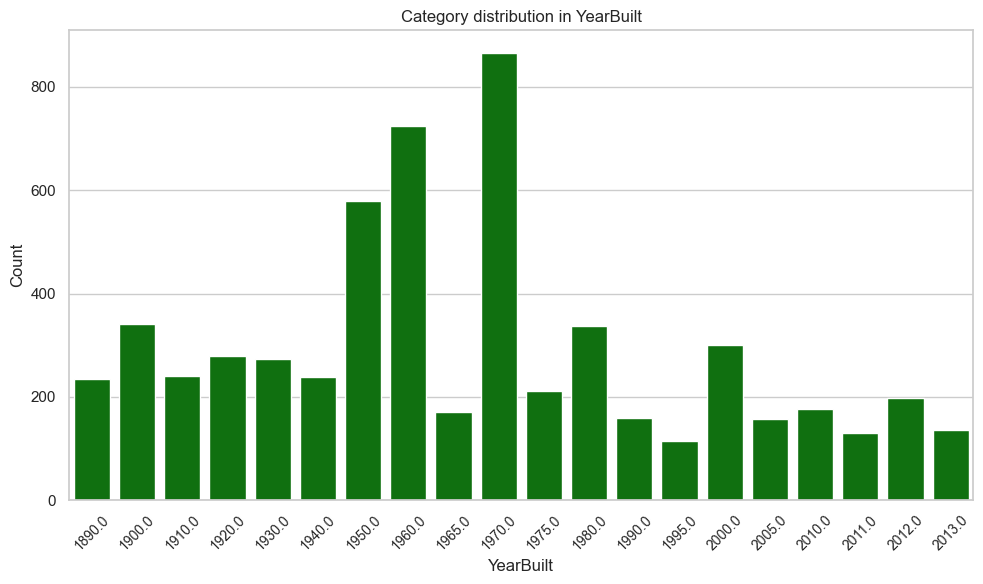

In [98]:
univariate_categorical('YearBuilt')

Unique values in variable -CouncilArea-
<StringArray>
[            'Yarra',     'Moonee Valley',      'Port Phillip',
           'Darebin',       'Hobsons Bay',       'Stonnington',
        'Boroondara',            'Monash',         'Glen Eira',
        'Whitehorse',       'Maribyrnong',           'Bayside',
          'Moreland',        'Manningham',           'Banyule',
         'Melbourne',          'Kingston',          'Brimbank',
              'Hume',                 nan,              'Knox',
         'Maroondah',             'Casey',            'Melton',
 'Greater Dandenong',         'Nillumbik',        'Whittlesea',
         'Frankston',    'Macedon Ranges',      'Yarra Ranges',
           'Wyndham',          'Cardinia',       'Unavailable',
         'Moorabool']
Length: 34, dtype: str
----------------------------------------------------------------------------------------------------
Most frequent value: Moreland
------------------------------------------------------------------

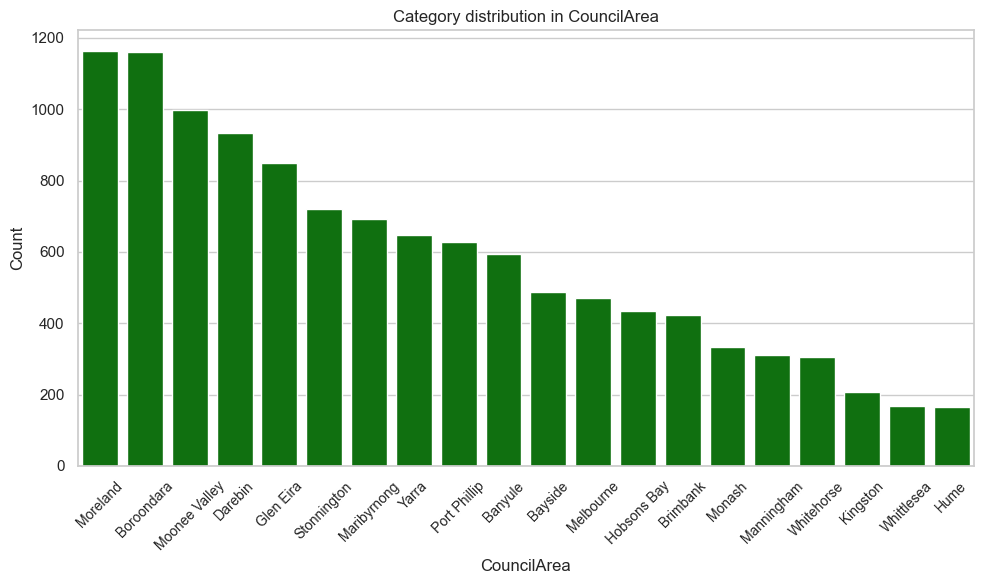

In [99]:
univariate_categorical('CouncilArea')

Unique values in variable -Regionname-
<StringArray>
[     'Northern Metropolitan',       'Western Metropolitan',
      'Southern Metropolitan',       'Eastern Metropolitan',
 'South-Eastern Metropolitan',           'Eastern Victoria',
          'Northern Victoria',           'Western Victoria']
Length: 8, dtype: str
----------------------------------------------------------------------------------------------------
Most frequent value: Southern Metropolitan
----------------------------------------------------------------------------------------------------
Percentage of categories
0   34.57
1   28.65
2   21.71
3   10.83
4    3.31
5    0.39
6    0.30
7    0.24
Name: count, dtype: float64
----------------------------------------------------------------------------------------------------
Descriptive statistics related to categories in -Regionname- variable.
         count
count     8.00
mean  1,697.50
std   1,896.83
min      32.00
25%      50.00
50%     960.50
75%   3,183.50
max   4,695

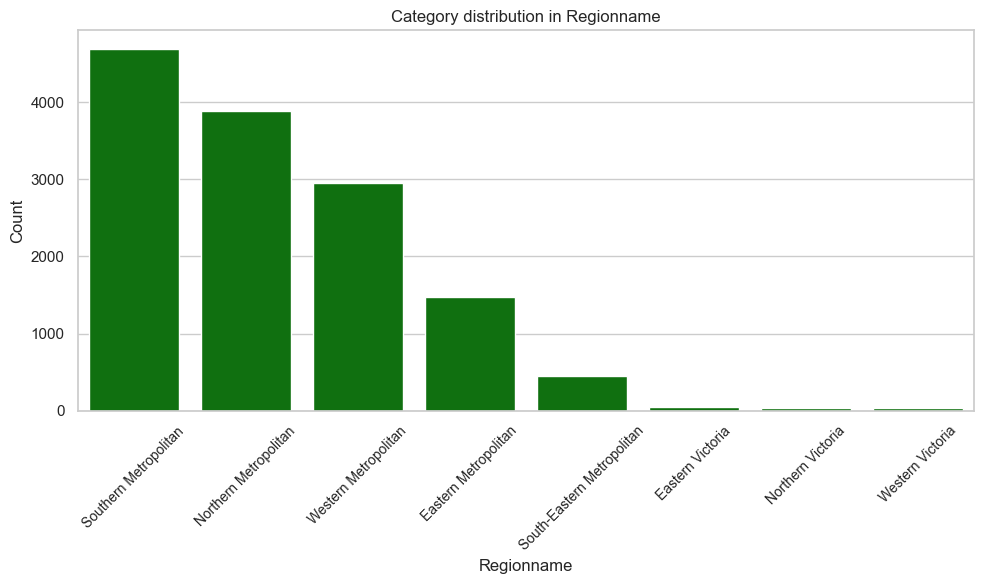

In [100]:
univariate_categorical('Regionname')

Unique values in variable -Propertycount-
[ 4019.  3464.  3280.  2211.  5301.  5132.  4836.  6567.  3052.  2894.
  4502.  2952.  5682.  7809.  6795. 10969.  4605.  3589. 10579.  6938.
 11918.  7082.  4480.  5678.  8920.  3265.  3106.  7822.  2379.  6923.
  5051.  3582.  2954. 11204.  3445.  4553.  9028.  1651.  4898.  8989.
  9264.  1308.  2970.  5825.  6244.  3593.  7570. 10412.  8870.  1071.
  2606.  5454.  2356. 11308.  2947.  2674.  3145.  5549.  1202.  5629.
  5263. 10331.  2671.   394.  3873.  4675.  8801.  4918. 17496.  2019.
  2079.  6232.  2555.  5498.  2291.  6821. 11364.  2651.  3692.  2309.
  7485.  8648.  7717. 14577. 21650. 14949.  3540.  2417.  5943. 14887.
  8400.  1223. 13240.  3284.  3755.  4217.  6763.  5457.  5420.  7217.
  2698.  2329.  2230.  6380.   802.  4380.  1369.  6543.  1543.   790.
  5533.   438.  1889.  6786.  3040.   588.  5070.  6482.  2890.  1554.
   851.  1414.  1808.  4442.  3578.  5058.  2185.   962.  2403.  3224.
   821.  1123.  4707.   984.   389.

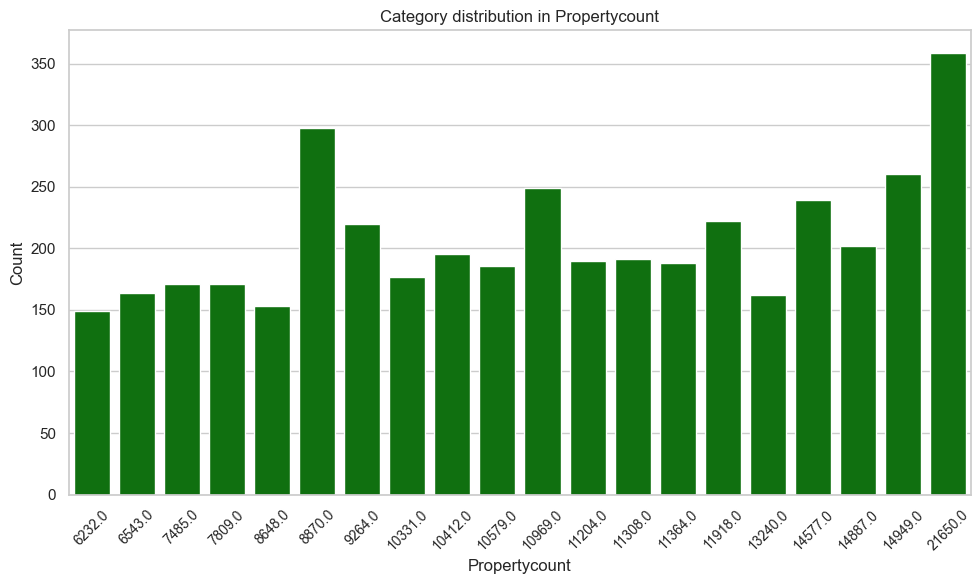

In [101]:
univariate_categorical('Propertycount')

In [102]:
#address cleaning


valid_street_types = {
    'St', 'Rd', 'Ct', 'Cr', 'Dr', 'Ave', 'Av', 'Pde', 'Pl', 'Tce',
    'Ln', 'Bvd', 'Wy', 'Cl', 'Cct', 'Sq', 'Hwy', 'Gr', 'Gdns', 'Grn',
    'Circuit', 'Way', 'Close', 'Qy', 'Res', 'La', 'Cir',
}

def extract_street_and_type(address):
    if pd.isna(address):
        return pd.Series([None, None])
        
    address_clean = address.split('/', 1)[-1] if '/' in address else address
    parts = address_clean.strip().split()

    if parts and (parts[0].isdigit() or re.match(r'\d+\w*', parts[0])):
        parts = parts[1:]

    street_type = next((word for word in parts if word in valid_street_types), None)
    street_parts = [word for word in parts if word not in valid_street_types]

    street = ' '.join(street_parts)
    return pd.Series([street, street_type])

mel_data[['Street', 'Street_Type']] = mel_data['Address'].apply(extract_street_and_type)


#full street types

street_type_full_map = {
    'St': 'Street',
    'Rd': 'Road',
    'La': 'Lane',
    'Gr': 'Grove',
    'Ct': 'Court',
    'Dr': 'Drive',
    'Pde': 'Parade',
    'Pl': 'Place',
    'Hwy': 'Highway',
    'Tce': 'Terrace',
    'Bvd': 'Boulevard',
    'Cl': 'Close',
    'Cct': 'Circuit',
    'Cir': 'Circle',
    'Sq': 'Square',
    'Res': 'Reserve',
    'Qy': 'Quay',
    'Gdns': 'Gardens',
    'Grn': 'Green',
    'Cr': 'Crescent',
    'Av': 'Avenue',
    'Ave': 'Avenue',
    'Wy': 'Way'
}

mel_data['Street_Type'] = mel_data['Street_Type'].replace(street_type_full_map)

Unique values in variable -Street-
<StringArray>
[      'Turner',    'Bloomburg',      'Charles',   'Federation',
         'Park',        'Yarra',    'Nicholson',      'Valiant',
    'Grosvenor',      'William',
 ...
      'Mudford',     'Hathaway',        'Airds',     'Nurlendi',
     'Winswood', 'chesterfield',       'Armagh',         'Mara',
       'Nuragi',       'Strada']
Length: 4189, dtype: str
----------------------------------------------------------------------------------------------------
Most frequent value: Barkly
----------------------------------------------------------------------------------------------------
Percentage of categories
0      0.55
1      0.47
2      0.42
3      0.41
4      0.35
       ... 
4184   0.01
4185   0.01
4186   0.01
4187   0.01
4188   0.01
Name: count, Length: 4189, dtype: float64
----------------------------------------------------------------------------------------------------
Descriptive statistics related to categories in -Street- variable

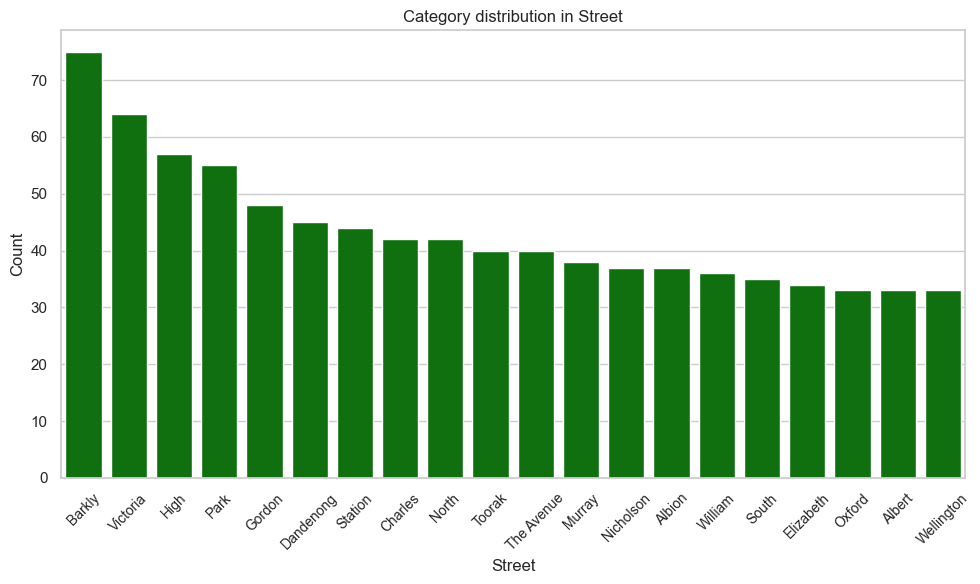

In [103]:
univariate_categorical('Street')

Unique values in variable -Street_Type-
<StringArray>
[   'Street',      'Lane',      'Road',     'Grove',     'Court',     'Drive',
    'Parade',     'Place',   'Highway',         nan,   'Terrace', 'Boulevard',
     'Close',   'Circuit',    'Circle',    'Square',   'Reserve',      'Quay',
   'Gardens',     'Green',  'Crescent',    'Avenue',       'Way']
Length: 23, dtype: str
----------------------------------------------------------------------------------------------------
Most frequent value: Street
----------------------------------------------------------------------------------------------------
Percentage of categories
0    59.78
1    20.84
2     4.55
3     3.32
4     2.39
5     2.31
6     1.56
7     1.24
8     1.13
9     0.74
10    0.50
11    0.39
12    0.35
13    0.30
14    0.19
15    0.18
16    0.08
17    0.05
18    0.03
19    0.03
20    0.01
21    0.01
Name: count, dtype: float64
-----------------------------------------------------------------------------------------------

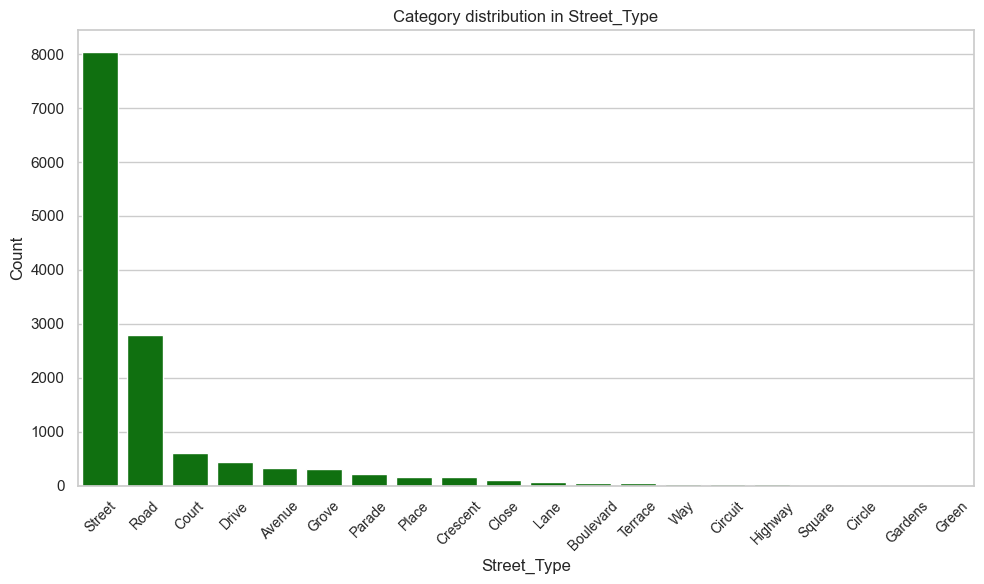

In [104]:
univariate_categorical('Street_Type')

In [105]:
mel_data['Date'] = pd.to_datetime(mel_data['Date'], dayfirst=True, errors='coerce')
mel_data['Total_Internal_Rooms'] = mel_data['Rooms'] + mel_data['Bathroom']
mel_data['Room_Bedroom_Ratio'] = mel_data['Rooms'] / (mel_data['Bedroom2'].replace(0, np.nan))

<Axes: >

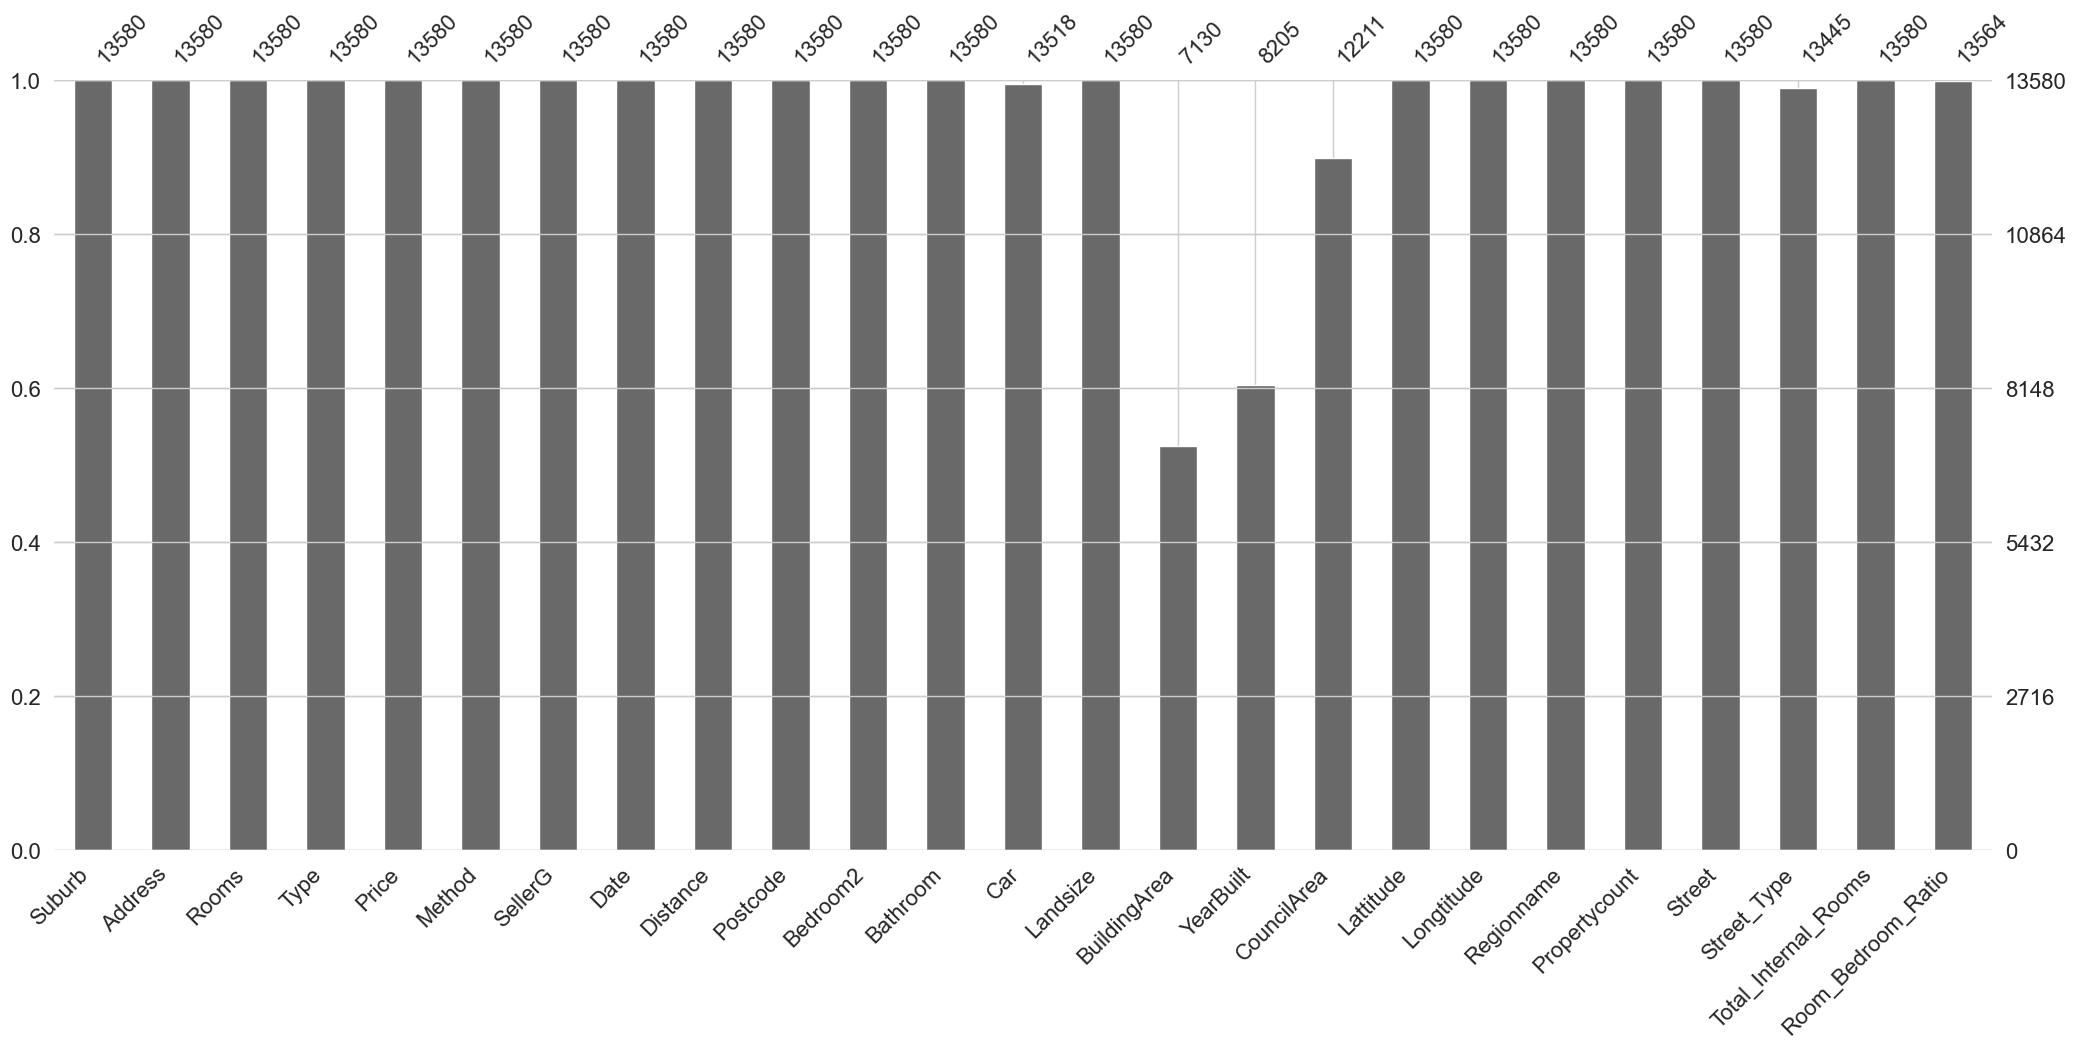

In [106]:
msno.bar(mel_data)

## Data Cleaning & Missing Values
Identifying and handling missing values before modelling

In [107]:
mel_Copy = mel_data.copy()

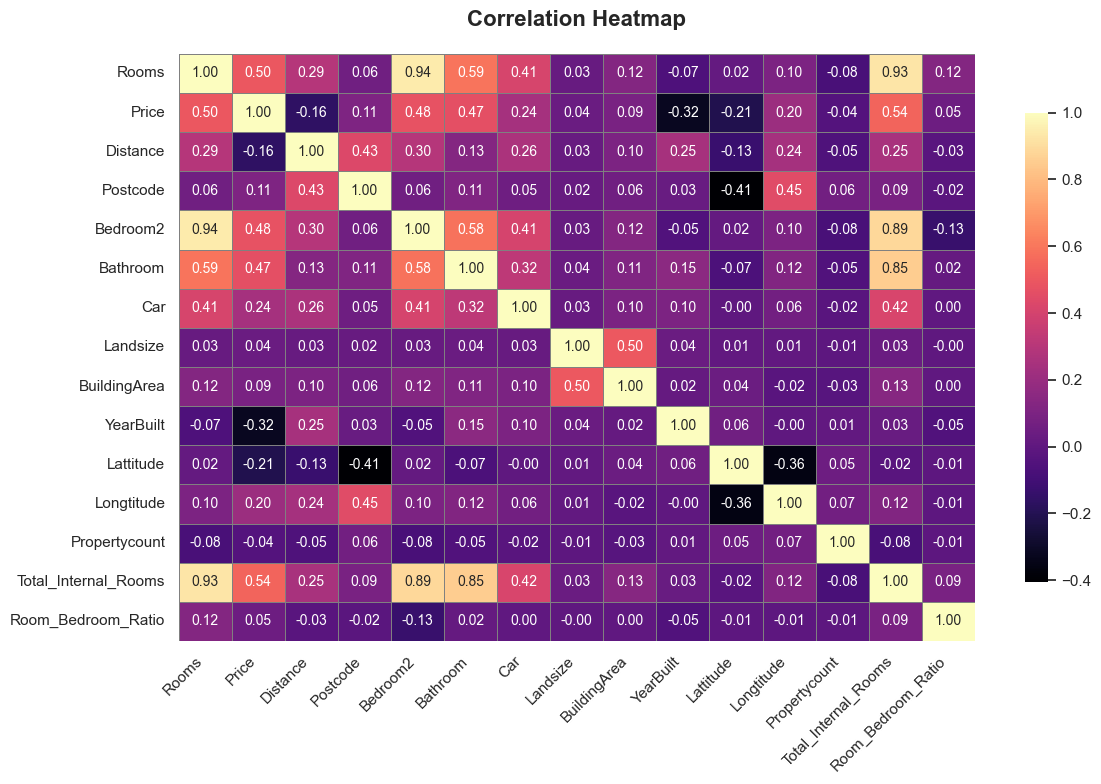

In [108]:
plt.figure(figsize=(12, 8))

heatmap = sb.heatmap(
    mel_Copy.select_dtypes([float, int]).corr(),
    annot=True,
    fmt=".2f",
    cmap="magma",
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size": 10},
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap", fontsize=16, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [109]:
mel_Copy = mel_Copy.drop(['Bedroom2', 'Bathroom', 'Rooms'], axis = 1)

In [110]:
print(mel_Copy.columns.tolist())

['Suburb', 'Address', 'Type', 'Price', 'Method', 'SellerG', 'Date', 'Distance', 'Postcode', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount', 'Street', 'Street_Type', 'Total_Internal_Rooms', 'Room_Bedroom_Ratio']


In [111]:
seller_count_df = mel_Copy['SellerG'].value_counts().reset_index()
less_occuring_sellers = seller_count_df[seller_count_df['count'] <= 3]['SellerG'].unique()
mel_Copy['SellerG'] = mel_Copy['SellerG'].apply(lambda x: x if x not in less_occuring_sellers else "other")

Mean price in Northern Metropolitan : 898171.0822622108
Mean price in Western Metropolitan : 866420.5200135686
Mean price in Southern Metropolitan : 1372963.3693290735
Mean price in Eastern Metropolitan : 1104079.6342624065
Mean price in South-Eastern Metropolitan : 922943.7844444445
Mean price in Eastern Victoria : 699980.7924528302
Mean price in Northern Victoria : 594829.268292683
Mean price in Western Victoria : 397523.4375


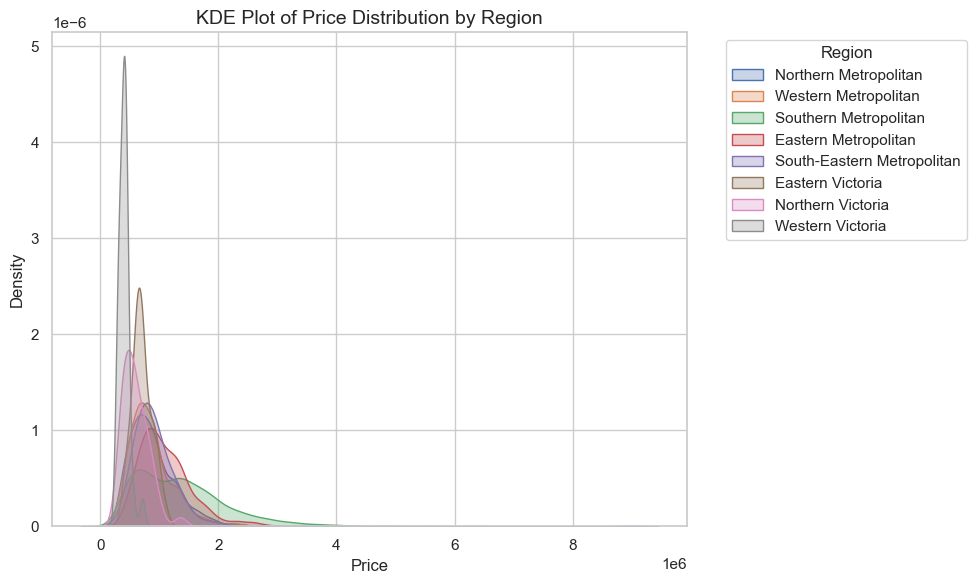

In [112]:
plt.figure(figsize=(10, 6))
sb.set(style="whitegrid")

regions = mel_Copy['Regionname'].unique()

for region in regions:
    mean_price = mel_Copy[mel_Copy['Regionname'] == region]['Price'].mean()
    print(f"Mean price in {region} : {mean_price}")
    sb.kdeplot(
        data=mel_Copy[mel_Copy['Regionname'] == region],
        x='Price',
        label=region,
        fill=True,
        alpha=0.3
    )

plt.title('KDE Plot of Price Distribution by Region', fontsize=14)
plt.xlabel('Price')
plt.ylabel('Density')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

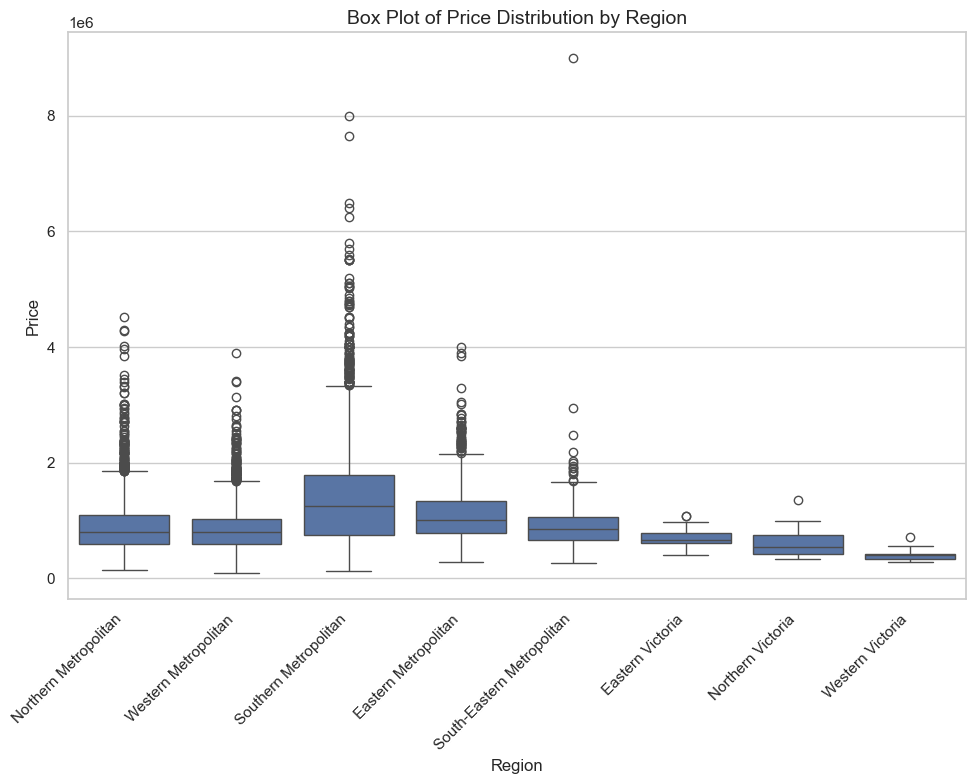

In [113]:
plt.figure(figsize=(10, 8))
sb.set(style="whitegrid")

sb.boxplot(
    data=mel_Copy,
    x='Regionname',
    y='Price'
)

plt.title('Box Plot of Price Distribution by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

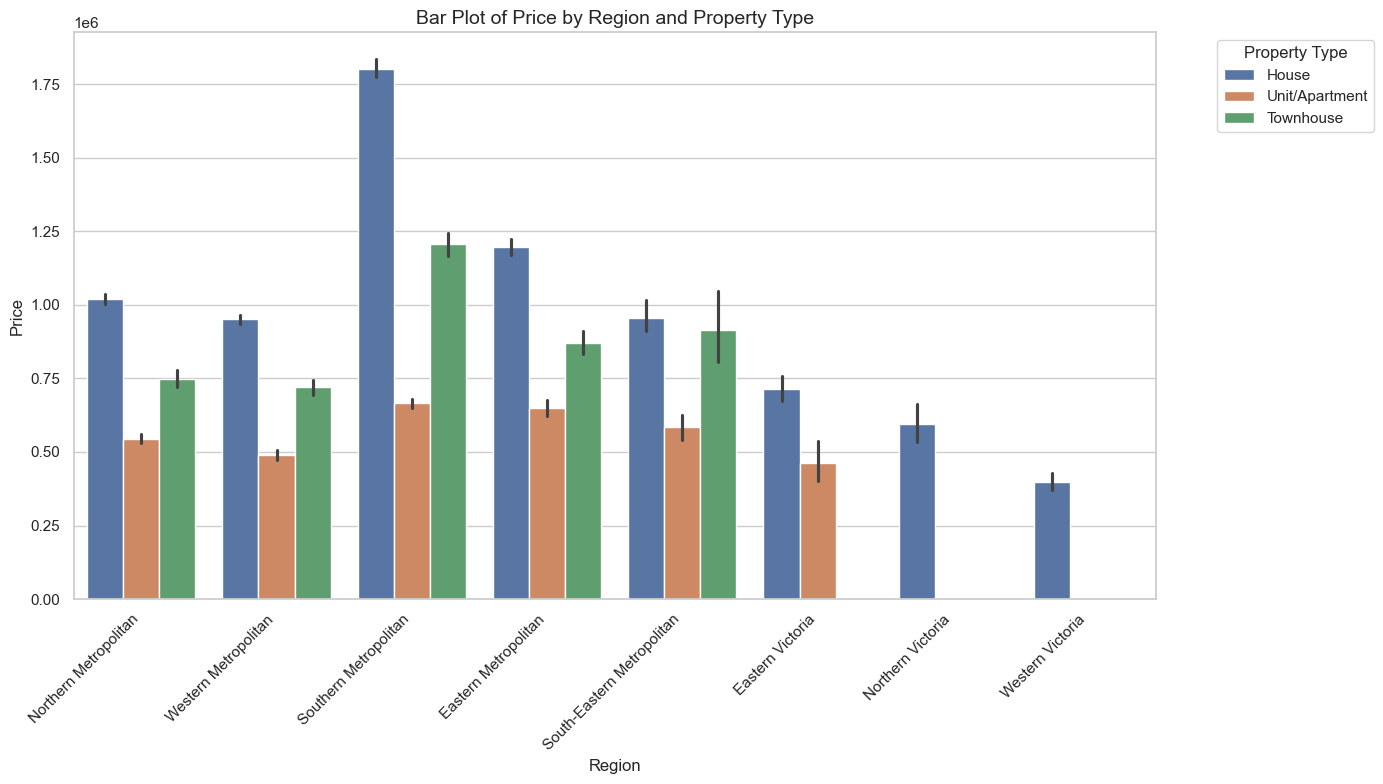

In [114]:
plt.figure(figsize=(14, 8))
sb.set(style="whitegrid")

sb.barplot(
    data=mel_Copy,
    x='Regionname',
    y='Price',
    hue='Type'
)

plt.title('Bar Plot of Price by Region and Property Type', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Property Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [115]:
suburb_summary = mel_Copy.groupby('Suburb').agg({
    'Price': 'mean',
    'Regionname': [
        lambda x: x.unique()[0],   # first unique name
        lambda x: len(x)
    ]
}).reset_index()

suburb_summary.columns = ['Suburb', 'Mean_Price', 'Regionname', 'count']

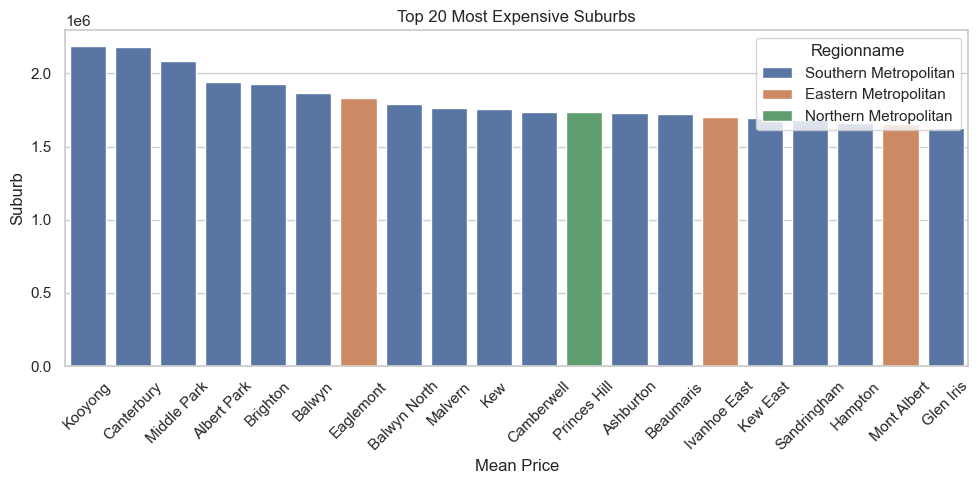

In [116]:
top_suburbs = suburb_summary.sort_values('Mean_Price', ascending=False).head(20)

plt.figure(figsize=(10, 5))
sb.barplot(data=top_suburbs, x='Suburb', y='Mean_Price', hue='Regionname')
plt.title('Top 20 Most Expensive Suburbs')
plt.xticks(rotation = 45)
plt.xlabel('Mean Price')
plt.ylabel('Suburb')
plt.tight_layout()
plt.show()

In [117]:
suburb_stats = mel_Copy.groupby('Suburb')['Price'].describe()

percentiles_dict = suburb_stats[['25%', '50%', '75%']].to_dict(orient='index')

def categorize_price(row, percentiles):
    suburb = row['Suburb']
    price = row['Price']
    
    if suburb not in percentiles:
        return 'Unknown'

    p25 = percentiles[suburb]['25%']
    p50 = percentiles[suburb]['50%']
    p75 = percentiles[suburb]['75%']

    if price <= p25:
        return 'Low-cost'
    elif price <= p50:
        return 'Affordable'
    elif price <= p75:
        return 'Moderate'
    else:
        return 'Luxury'

mel_Copy['Price_Category'] = mel_Copy.apply(lambda row: categorize_price(row, percentiles_dict), axis=1)

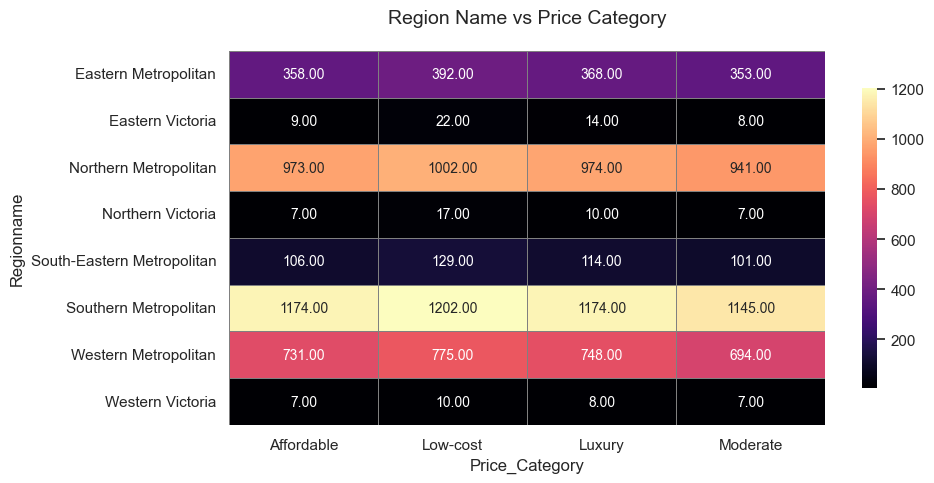

In [118]:
region_category_counts = pd.crosstab(
    mel_Copy['Regionname'],
    mel_Copy['Price_Category']
)

plt.figure(figsize=(10, 5))

heatmap = sb.heatmap(
    region_category_counts,
    annot=True,
    fmt=".2f",
    cmap="magma",
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size": 10},
    cbar_kws={"shrink": 0.8}
)

plt.title("Region Name vs Price Category", fontsize=14, pad=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [119]:
def categorize_distance(dist):
    if dist <= 5:
        return 'Very Close'
    elif dist <= 10:
        return 'Close'
    elif dist <= 20:
        return 'Moderate'
    elif dist <= 30:
        return 'Far'
    else:
        return 'Very Far'

mel_Copy['Distance_Category'] = mel_Copy['Distance'].apply(categorize_distance)

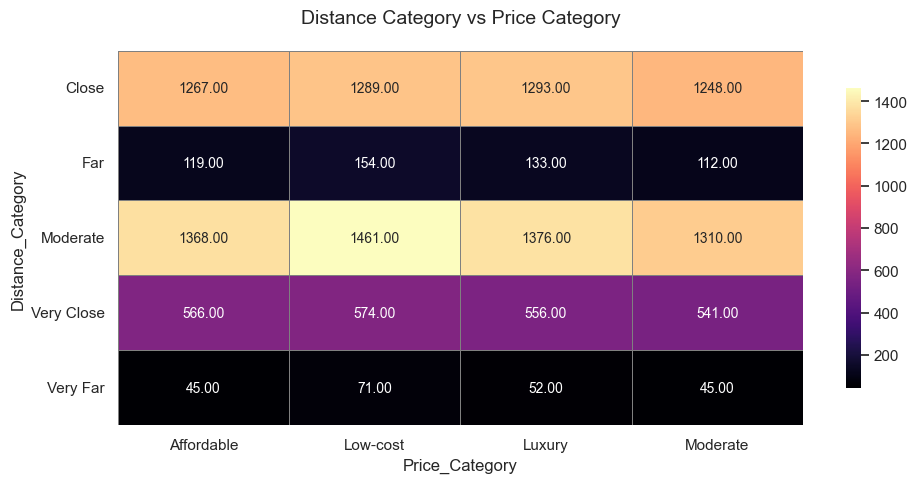

In [120]:
distance_category_counts = pd.crosstab(
    mel_Copy['Distance_Category'],
    mel_Copy['Price_Category']
)

plt.figure(figsize=(10, 5))

heatmap = sb.heatmap(
    distance_category_counts,
    annot=True,
    fmt=".2f",
    cmap="magma",
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size": 10},
    cbar_kws={"shrink": 0.8}
)

plt.title("Distance Category vs Price Category", fontsize=14, pad=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

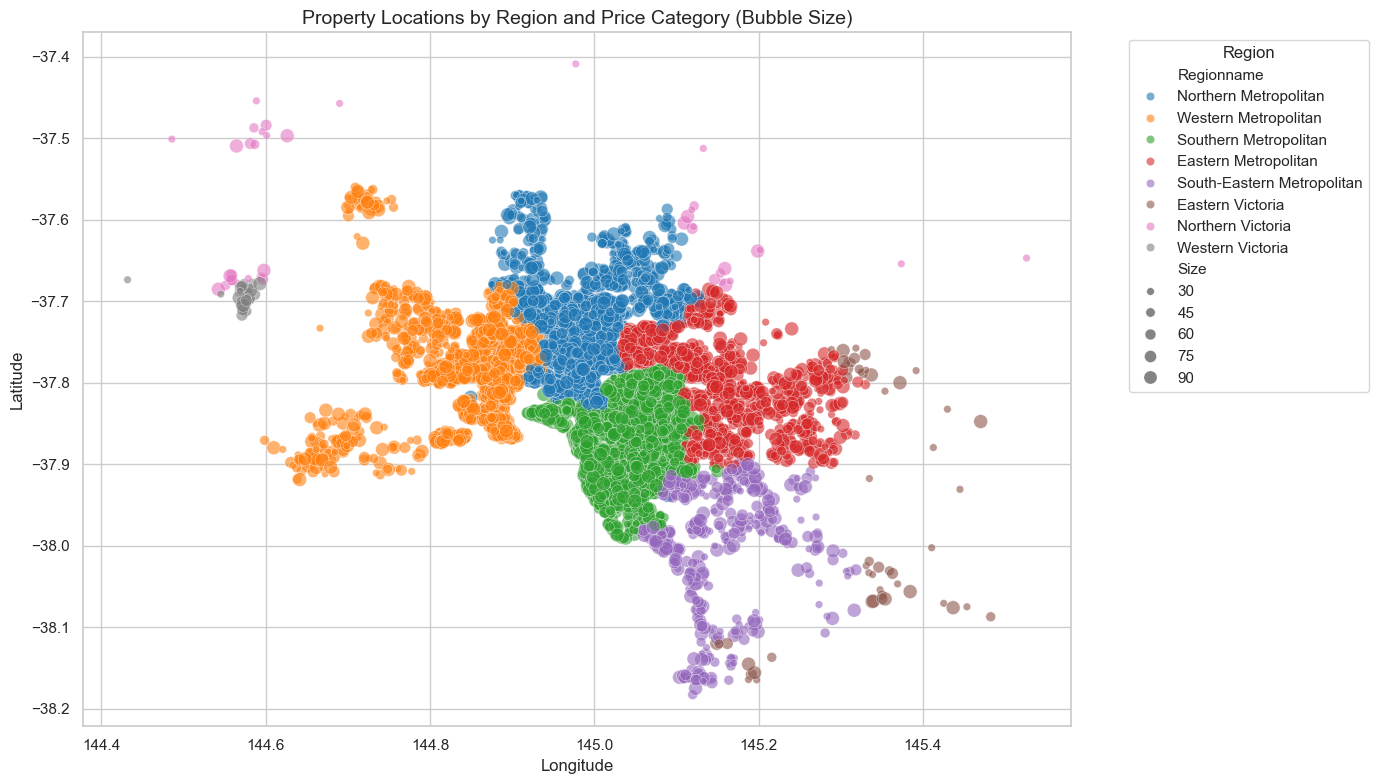

In [121]:
size_mapping = {
    'Low-cost': 30,
    'Affordable': 50,
    'Moderate': 70,
    'Luxury': 100
}
mel_Copy['Size'] = mel_Copy['Price_Category'].map(size_mapping)

plt.figure(figsize=(14, 8))
sb.set(style="whitegrid")

sb.scatterplot(
    data=mel_Copy,
    x='Longtitude',
    y='Lattitude',
    hue='Regionname',
    size='Size',
    sizes=(30, 100),
    alpha=0.6,
    palette='tab10',
    edgecolor='w',
    linewidth=0.4,
    legend='brief'
)

plt.title('Property Locations by Region and Price Category (Bubble Size)', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Region')
plt.tight_layout()
plt.show()

In [122]:
seller_price_dist = pd.crosstab(mel_Copy['SellerG'], mel_Copy['Price_Category'])

seller_price_ratio = seller_price_dist.div(seller_price_dist.sum(axis=1), axis=0)

seller_price_ratio['Dominant_Category'] = seller_price_ratio.idxmax(axis=1)

seller_preference_map = seller_price_ratio['Dominant_Category'].to_dict()

mel_Copy['Seller_Preference'] = mel_Copy['SellerG'].map(seller_preference_map)

In [123]:
mel_Copy['Building_Density'] = mel_Copy['Total_Internal_Rooms'] / mel_Copy['Landsize']
mel_Copy['Land_per_Room'] = mel_Copy['Landsize'] / mel_Copy['Total_Internal_Rooms']

In [124]:
mel_Copy['Car'] = mel_Copy['Car'].fillna(mel_Copy['Car'].mean())
mel_Copy['Street_Type'] = mel_Copy['Street_Type'].fillna(mel_Copy['Street_Type'].mode()[0])
mel_Copy['Room_Bedroom_Ratio'] = mel_Copy['Room_Bedroom_Ratio'].fillna(mel_Copy['Room_Bedroom_Ratio'].mean())
mel_Copy['CouncilArea'] = mel_Copy['CouncilArea'].fillna(mel_Copy['CouncilArea'].mode()[0])

In [125]:
mel_Copy['Postcode'] = mel_Copy['Postcode'].astype(object)

In [126]:
mel_Copy = mel_Copy.replace([np.inf, -np.inf], np.nan)

## Feature Engineering & Preprocessing
Dropping low-value or redundant columns, encoding categorical variables using Ordinal Encoding, and prepping features for training

In [139]:
feature_selection_df = mel_Copy.dropna().drop(['Address', 'Date', 'Size'], axis = 1)

data_label_encoded = feature_selection_df.copy()
categorical_cols = feature_selection_df.select_dtypes(include=['str', 'category']).columns

for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

X_label = data_label_encoded.drop('Price', axis=1)
y_label = data_label_encoded['Price']

[array(['Abbotsford', 'Aberfeldie', 'Airport West', 'Albanvale',
       'Albert Park', 'Albion', 'Alphington', 'Altona', 'Altona Meadows',
       'Altona North', 'Ardeer', 'Armadale', 'Ascot Vale', 'Ashburton',
       'Ashwood', 'Aspendale', 'Avondale Heights', 'Balaclava', 'Balwyn',
       'Balwyn North', 'Bayswater', 'Bayswater North', 'Beaconsfield',
       'Beaconsfield Upper', 'Beaumaris', 'Bellfield', 'Bentleigh',
       'Bentleigh East', 'Berwick', 'Black Rock', 'Blackburn',
       'Blackburn North', 'Blackburn South', 'Bonbeach', 'Boronia',
       'Box Hill', 'Braybrook', 'Briar Hill', 'Brighton', 'Brighton East',
       'Broadmeadows', 'Brookfield', 'Brooklyn', 'Brunswick',
       'Brunswick East', 'Brunswick West', 'Bulleen', 'Bundoora',
       'Burnley', 'Burnside', 'Burnside Heights', 'Burwood',
       'Burwood East', 'Cairnlea', 'Camberwell', 'Campbellfield',
       'Canterbury', 'Carlton', 'Carlton North', 'Carnegie',
       'Caroline Springs', 'Carrum', 'Carrum Downs', '

## Feature Selection
Using permutation importance and Recursive Feature Elimination (RFE) to identify most predictive features and reduce noise.

In [128]:
def compute_feature_importances(X, y):
    feature_names = X.columns

    # 1. Random Forest Importance
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X, y)
    rf_importance = rf.feature_importances_

    # 2. Gradient Boosting Importance
    gb = GradientBoostingRegressor(random_state=42)
    gb.fit(X, y)
    gb_importance = gb.feature_importances_

    # 3. Permutation Importance (on test set)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf_perm = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_perm.fit(X_train, y_train)
    perm = permutation_importance(rf_perm, X_test, y_test, n_repeats=30, random_state=42)
    perm_importance = perm.importances_mean

    # 4. Recursive Feature Elimination (RFE)
    rfe_estimator = RandomForestRegressor(random_state=42)
    rfe = RFE(rfe_estimator, n_features_to_select=X.shape[1], step=1)
    rfe.fit(X, y)
    rfe_support = rfe.support_
    rfe_scores = np.zeros(X.shape[1])
    rfe_scores[rfe_support] = rfe.estimator_.feature_importances_

    fi_df = pd.DataFrame({
        'feature': feature_names,
        'rf_importance': rf_importance,
        'gb_importance': gb_importance,
        'permutation_importance': perm_importance,
        'rfe_score': rfe_scores
    })

    fi_df['mean_importance'] = fi_df[['rf_importance', 'gb_importance', 'permutation_importance', 'rfe_score']].mean(axis=1)
    fi_df = fi_df.sort_values(by='mean_importance', ascending=False).reset_index(drop=True)

    return fi_df

fi_results = compute_feature_importances(X_label, y_label)

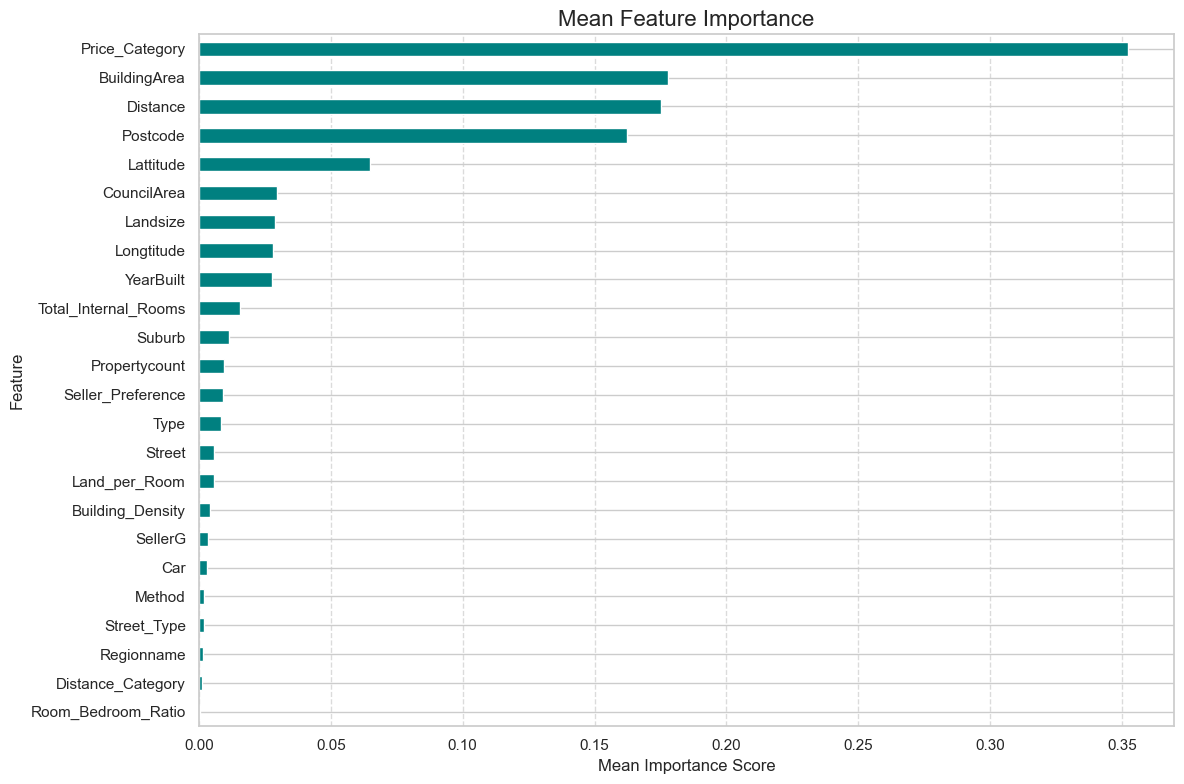

In [129]:
fi_results = fi_results.set_index('feature')

plt.figure(figsize=(12, 8))
fi_results['mean_importance'].sort_values().plot(
    kind='barh',
    figsize=(12, 8),
    color='teal'
)
plt.title("Mean Feature Importance", fontsize=16)
plt.xlabel("Mean Importance Score")
plt.ylabel("Feature")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [130]:
def best_skew_fix_with_clipping(df, columns, z_thresh=3):
    import numpy as np
    import pandas as pd
    from scipy.stats import zscore

    transformations = {
        'none': lambda x: x,
        'sqrt': lambda x: np.sqrt(x),
        'cbrt': lambda x: np.cbrt(x),
        'log': lambda x: np.log(x + 1e-6),  # avoid log(0)
        'log1p': np.log1p
    }

    def clip_outliers(series, method='zscore'):
        if method == 'zscore':
            z_scores = zscore(series)
            mask = np.abs(z_scores) < z_thresh
            lower = series[mask].min()
            upper = series[mask].max()
        elif method == 'iqr':
            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
        else:
            lower, upper = series.min(), series.max()

        return series.clip(lower, upper)

    best_transforms = {}
    df_result = df.copy()

    for col in columns:
        best_skew = np.inf
        best_transform = None
        best_result_series = df[col]

        for tname, tfunc in transformations.items():
            try:
                transformed = tfunc(df[col])
                for method in ['zscore', 'iqr']:
                    clipped = clip_outliers(transformed, method)
                    skew_val = clipped.skew()
                    if abs(skew_val) < abs(best_skew):
                        best_skew = skew_val
                        best_transform = (tname, method)
                        best_result_series = clipped
            except Exception:
                continue

        df_result[col] = best_result_series
        best_transforms[col] = {
            'Transformation': best_transform[0] if best_transform else 'none',
            'Outlier_Method': best_transform[1] if best_transform else 'none',
            'Final_Skewness': best_skew
        }

    return df_result, pd.DataFrame(best_transforms).T

columns_to_transform = ['Distance', 'Total_Internal_Rooms', 'Landsize', 'Longtitude', 'Lattitude', 'Propertycount']

transformed_data, transform_log = best_skew_fix_with_clipping(mel_Copy, columns_to_transform)

In [131]:
columns_to_drop = ['Address', 'Method', 'SellerG', 'Date', 'Car', 'Regionname', 'Street',
       'Street_Type', 'Room_Bedroom_Ratio', 'Distance_Category', 'Size',
       'Seller_Preference', 'Building_Density', 'Land_per_Room']

transformed_data.drop(columns_to_drop, axis = 1, inplace = True)

In [132]:
transformed_data['Postcode'] = transformed_data['Postcode'].astype(object)

In [133]:
pd.set_option('display.float_format', '{:,.2f}'.format)

transformed_data['Price'] = transformed_data['Price'].apply(np.log1p)

## Model Training & Hyperparameter Tuning
Comparing 7 regression models using GridSearchCV with 5 fold cross validation.
Models: ElasticNet, Decision Tree, Random Forest, Extra Trees, XGBoost, Gradient Boosting, LightGBM.

In [134]:
numerical_features = ['Distance', 'Landsize', 'Lattitude', 'Longtitude',
       'Propertycount', 'Total_Internal_Rooms']

categorical_features = ['Suburb', 'Type', 'Postcode', 'CouncilArea', 'Price_Category']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

X = transformed_data.drop('Price', axis=1)
y = transformed_data['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    # 'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000),
    # 'Ridge': Ridge(),
    # 'Lasso': Lasso(max_iter=10000),
    # 'SVR' : SVR(),
    # 'KNN': KNeighborsRegressor(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'ExtraTrees': ExtraTreesRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'GradientBoosting' : GradientBoostingRegressor(random_state=42),
    'LightGBM' : LGBMRegressor(random_state=42, verbose=-1)
}

param_grids = {
    # 'Ridge': {
    #     'alpha': [0.01, 0.1, 1, 10]
    # },
    # 'Lasso': {
    #     'alpha': [0.0001, 0.01, 1]
    # },
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1],
        'l1_ratio': [0.2, 0.5, 0.8]
    },
    # 'SVR' : {
    # 'C': [0.1, 1, 10],
    # 'kernel': ['rbf', 'linear'],
    # 'epsilon': [0.1, 0.2]
    # },
    # 'KNN': {
    #     'n_neighbors': [3, 7, 11],
    #     'weights': ['uniform', 'distance'],
    #     'p': [1, 2]
    # },
    'DecisionTree': {
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'RandomForest': {
        'n_estimators': [100],
        'max_depth': [None, 10],
        'min_samples_split': [2],
        'min_samples_leaf': [1],
        'max_features': ['sqrt']
    },
    'ExtraTrees': {
        'n_estimators': [100],
        'max_depth': [None, 10],
        'min_samples_split': [2],
        'min_samples_leaf': [1],
        'max_features': ['sqrt']
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.5],
        'max_depth': [3, 7, 9],
        'subsample': [0.8],
        'colsample_bytree': [0.8]
    },
    'GradientBoosting' : {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
    },
    'LightGBM' : {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.5],
    'num_leaves': [31, 50],
    'max_depth': [-1, 10]
    }
}

best_model_name = None
best_model_instance = None
lowest_rmse = float('inf')
model_results = []

for name, model in models.items():
    print(f"Tuning/Fitting {name}...")
    
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    param_grid = {
        f'regressor__{key}': val
        for key, val in param_grids.get(name, {}).items()
    }

    if param_grid:
        grid = GridSearchCV(pipe, param_grid=param_grid, cv=3,
                            scoring='neg_mean_squared_error', n_jobs=-1)
        grid.fit(X_train, y_train)
        best_pipeline = grid.best_estimator_

        best_params = grid.best_params_
        print(best_params)
    else:
        best_pipeline = pipe.fit(X_train, y_train)

    y_pred = best_pipeline.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    input_example = X_test.iloc[:5]  # a small sample is enough
    y_pred_sample = best_pipeline.predict(input_example)

    model_results.append({
        'Model': name,
        'RMSE': rmse,
        'R2': r2
    })

    if rmse < lowest_rmse:
        lowest_rmse = rmse
        best_model_name = name
        best_model_instance = best_pipeline


# Calculate train R²
train_r2 = r2_score(y_train, best_model_instance.predict(X_train))

# Calculate test R² (already done earlier, but printing again for clarity)
test_r2 = r2_score(y_test, best_model_instance.predict(X_test))

print(f"\n📈 R² Score on Training Set: {train_r2:.4f}")
print(f"📉 R² Score on Testing Set: {test_r2:.4f}")

results_df = pd.DataFrame(model_results).sort_values(by='RMSE').reset_index(drop=True)
print(f"\n✅ Best model: {best_model_name} with RMSE = {lowest_rmse:.4f}")

Tuning/Fitting ElasticNet...
{'regressor__alpha': 0.01, 'regressor__l1_ratio': 0.2}
Tuning/Fitting DecisionTree...
{'regressor__max_depth': 20, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5}
Tuning/Fitting RandomForest...
{'regressor__max_depth': None, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}
Tuning/Fitting ExtraTrees...
{'regressor__max_depth': None, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}
Tuning/Fitting XGBoost...
{'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 9, 'regressor__n_estimators': 200, 'regressor__subsample': 0.8}
Tuning/Fitting GradientBoosting...
{'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__n_estimators': 200}
Tuning/Fitting LightGBM...
{'regressor__learning_rate': 0.1, 'regressor__max_dep

In [135]:
train_preds = best_model_instance.predict(X_train)

train_comparison_df = pd.DataFrame({
    'Actual_Price': y_train,
    'Predicted_Price': train_preds
})

train_comparison_df['Error'] = train_comparison_df['Actual_Price'] - train_comparison_df['Predicted_Price']
train_comparison_df['Absolute_Error'] = train_comparison_df['Error'].abs()

In [136]:
test_preds = best_model_instance.predict(X_test)

test_comparison_df = pd.DataFrame({
    'Actual_Price': y_test,
    'Predicted_Price': test_preds
})

test_comparison_df['Error'] = test_comparison_df['Actual_Price'] - test_comparison_df['Predicted_Price']
test_comparison_df['Absolute_Error'] = test_comparison_df['Error'].abs()

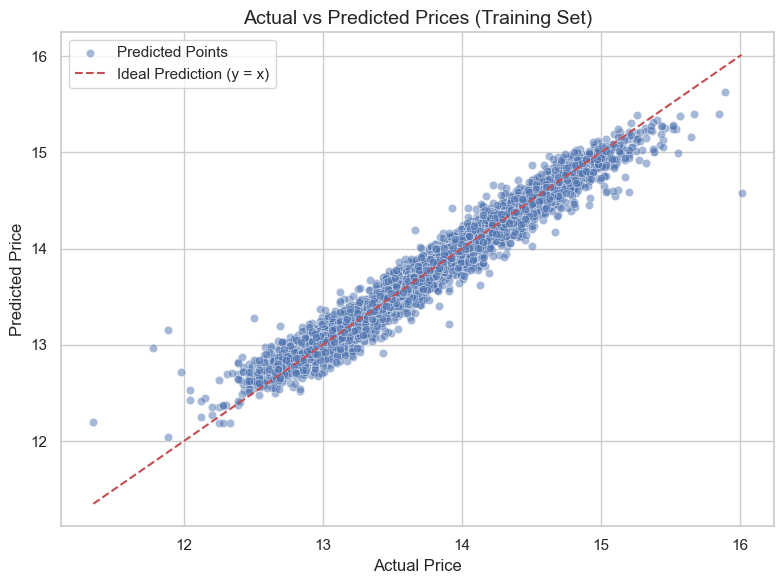

In [137]:
plt.figure(figsize=(8, 6))
sb.scatterplot(data=train_comparison_df, x='Actual_Price', y='Predicted_Price', alpha=0.5, label='Predicted Points')

plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    'r--',
    label='Ideal Prediction (y = x)'
)

plt.title('Actual vs Predicted Prices (Training Set)', fontsize=14)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

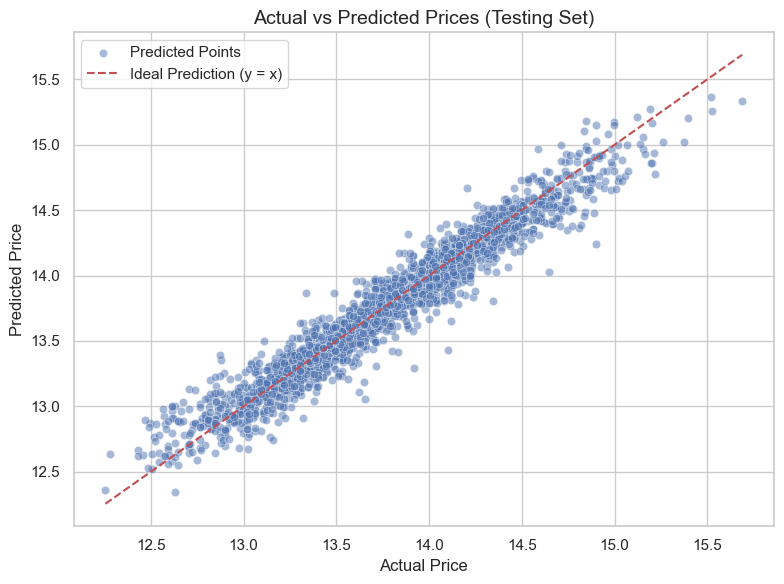

In [138]:
plt.figure(figsize=(8, 6))
sb.scatterplot(data=test_comparison_df, x='Actual_Price', y='Predicted_Price', alpha=0.5, label='Predicted Points')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label='Ideal Prediction (y = x)'
)
plt.title('Actual vs Predicted Prices (Testing Set)', fontsize=14)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Conclusion
LightGBM achieved the best performance with **R² = 0.94** on the test set and RMSE = 0.0165. Tree-based ensemble methods consistently outperformed linear models on this dataset, likely due to the non-linear relationships between location features and price.